# Student FULL name: Nouviboth RA
# Student number: 60858559

Acknowledgement Statement by students: <br>
Please keep one acknowledgment from the following<br>
	I acknowledge that I have not used GenAI (e. g., ChatGPT) in drafting and proofreading of this assignment.<br>
	I acknowledge that I have only used GenAI (e.g., ChatGPT) in drafting and proofreading this assignment, which is permitted in the assignment instructions. <br>

#  Answer to Section 1 (-2 if not provided) (answer in one cell): 

Lighting suppliers across Australia offer a huge selection of products such as traditional fixtures to modern LED. According Expert Market Research (2025), in 2024, Australian lighting industry worth AUD12.45 billion, showing a significant growth which is driven by the increase of sustainable and efficient energy. The market is estimated to grow with a compound annual growth rate of 8.5% until 2034. This rate will expand the market size to AUD28.15 billion. This expansion is primarily due to the extensive uses of energy-efficient lighting technologies in residential, commercial, and industrial.

Reference: <br>
Expert Market Research (Claight Corporation). (2025). Australia Lighting Market Outlook - forecast trends, market size, share and Growth Analysis Report (2025-2034). PR. https://www.expertmarketresearch.com.au/reports/australia-lighting-market/toc#toc-div 

# Answer to Section 2: EDA (20 Marks) - add as many cell as needed 

In [1]:
#Import pandas function to work on the dataset, reading, cleaning
import pandas as pd

#Import matplotlib function for plotting library
import matplotlib.pyplot as plt

#Import seaborn for higher level of plotting
import seaborn as sns

#Import numpy to use for math calculation
import numpy as np

#Import scipy for calculating statistical function
from scipy import stats

In [2]:
#load data into a DataFrame by using pandas
assessment = pd.read_excel("Assessment 01.xlsx")

# Display the DataFrame with 1 row only
assessment.head(1)

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_l1_name,business_chain_l1_code,business_area_code,light_source,salesperson_code
0,20191025.0,400.0,5.0,Landscape,3.33,Metro Electrical Distributors,MED,COM,Traditional,T612


# DATA CLEANING

In [3]:
#Display a summary of the dataframe, including the range index, dtypes, column headers, and memory usage
assessment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1037205 entries, 0 to 1037204
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   sales_date              951128 non-null   float64
 1   customer_district_code  951177 non-null   float64
 2   item_type               951177 non-null   float64
 3   item_type_description   1037194 non-null  object 
 4   sales                   1036784 non-null  object 
 5   business_chain_l1_name  951177 non-null   object 
 6   business_chain_l1_code  951177 non-null   object 
 7   business_area_code      951177 non-null   object 
 8   light_source            951177 non-null   object 
 9   salesperson_code        1037188 non-null  object 
dtypes: float64(3), object(7)
memory usage: 79.1+ MB


In [4]:
#Convert the data in sales column to numeric value
assessment['sales']=pd.to_numeric(assessment['sales'], errors='coerce')

In [5]:
#Display the summary of the dataframe
assessment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1037205 entries, 0 to 1037204
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   sales_date              951128 non-null   float64
 1   customer_district_code  951177 non-null   float64
 2   item_type               951177 non-null   float64
 3   item_type_description   1037194 non-null  object 
 4   sales                   1036781 non-null  float64
 5   business_chain_l1_name  951177 non-null   object 
 6   business_chain_l1_code  951177 non-null   object 
 7   business_area_code      951177 non-null   object 
 8   light_source            951177 non-null   object 
 9   salesperson_code        1037188 non-null  object 
dtypes: float64(4), object(6)
memory usage: 79.1+ MB


In [6]:
#Finding missing values and sum the values to get total amount
assessment.isnull().sum()

sales_date                86077
customer_district_code    86028
item_type                 86028
item_type_description        11
sales                       424
business_chain_l1_name    86028
business_chain_l1_code    86028
business_area_code        86028
light_source              86028
salesperson_code             17
dtype: int64

In [7]:
#Filter the DataFrame only to include rows with at least one missing value.
row_miss = assessment[assessment.isna().any(axis=1)]
row_miss 

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_l1_name,business_chain_l1_code,business_area_code,light_source,salesperson_code
16,20231021.0,300.0,7.0,NaN,5.78,Independent Retailers Association,ZZ2,LMP,Traditional,P342
59,20221019.0,300.0,5.0,NaN,13.10,Metro Electrical Distributors,MED,LMP,Traditional,T203
111,20221009.0,300.0,7.0,NaN,19.90,ProLighting Specialists,ZZ3,LMP,Traditional,P347
192,20191021.0,200.0,7.0,NaN,17.30,Builders Supply Network,ZZ1,LMP,Traditional,P415
236,20201008.0,400.0,7.0,NaN,11.50,Builders Supply Network,ZZ1,LMP,Traditional,P248
...,...,...,...,...,...,...,...,...,...,...
1037200,NaN,NaN,NaN,0,1.10,NaN,NaN,NaN,NaN,T431
1037201,NaN,NaN,NaN,0,1.10,NaN,NaN,NaN,NaN,T600
1037202,NaN,NaN,NaN,0,1.10,NaN,NaN,NaN,NaN,T600
1037203,NaN,NaN,NaN,0,1.10,NaN,NaN,NaN,NaN,T215


In [8]:
#Filter the DataFrame only to include rows with missing value up to 4.
assessment = assessment[assessment.isnull().sum(axis=1) < 5]

In [9]:
#Showing the dataframe with missing value per row after flitering in cell 8
row_miss = assessment[assessment.isna().any(axis=1)]
row_miss 

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_l1_name,business_chain_l1_code,business_area_code,light_source,salesperson_code
16,20231021.0,300.0,7.0,NaN,5.78,Independent Retailers Association,ZZ2,LMP,Traditional,P342
59,20221019.0,300.0,5.0,NaN,13.10,Metro Electrical Distributors,MED,LMP,Traditional,T203
111,20221009.0,300.0,7.0,NaN,19.90,ProLighting Specialists,ZZ3,LMP,Traditional,P347
192,20191021.0,200.0,7.0,NaN,17.30,Builders Supply Network,ZZ1,LMP,Traditional,P415
236,20201008.0,400.0,7.0,NaN,11.50,Builders Supply Network,ZZ1,LMP,Traditional,P248
...,...,...,...,...,...,...,...,...,...,...
717533,NaN,300.0,5.0,Landscape,47.50,Metro Electrical Distributors,MED,LMP,Traditional,P342
758206,20171027.0,400.0,8.0,Road-and-street,20.59,NextGen Electrical Solutions,NES,COM,Traditional,NaN
759861,20161002.0,600.0,7.0,Decorative,58.60,ProLighting Specialists,ZZ3,LMP,Traditional,NaN
760224,20181030.0,200.0,1.0,Wall-mount,144.19,NextGen Electrical Solutions,NES,SUR,Traditional,NaN


In [10]:
#Dropping any duplicated value from the dataframe.
assessment = assessment.drop_duplicates()

In [11]:
#Count missing values and sum the values to get total amount after filtering
assessment.isnull().sum()

sales_date                49
customer_district_code     0
item_type                  0
item_type_description     10
sales                      7
business_chain_l1_name     0
business_chain_l1_code     0
business_area_code         0
light_source               0
salesperson_code          17
dtype: int64

In [13]:
#Display the summary of the dataframe
assessment.info()

<class 'pandas.core.frame.DataFrame'>
Index: 940517 entries, 0 to 951176
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   sales_date              940468 non-null  float64
 1   customer_district_code  940517 non-null  float64
 2   item_type               940517 non-null  float64
 3   item_type_description   940507 non-null  object 
 4   sales                   940510 non-null  float64
 5   business_chain_l1_name  940517 non-null  object 
 6   business_chain_l1_code  940517 non-null  object 
 7   business_area_code      940517 non-null  object 
 8   light_source            940517 non-null  object 
 9   salesperson_code        940500 non-null  object 
dtypes: float64(4), object(6)
memory usage: 78.9+ MB


In [14]:
#Define and count the missing values and sum the values to get total amount
missing_values_column = assessment.isnull().sum()
print(missing_values_column)

sales_date                49
customer_district_code     0
item_type                  0
item_type_description     10
sales                      7
business_chain_l1_name     0
business_chain_l1_code     0
business_area_code         0
light_source               0
salesperson_code          17
dtype: int64


In [15]:
#Remove the subset of missing values from the column sales_date
assessment = assessment.dropna(subset='sales_date')

##Count missing values and sum the values to check
assessment.isna().sum()

sales_date                 0
customer_district_code     0
item_type                  0
item_type_description     10
sales                      7
business_chain_l1_name     0
business_chain_l1_code     0
business_area_code         0
light_source               0
salesperson_code          17
dtype: int64

In [16]:
# Filter rows where 'item type' is either '7.0'
filtered_item_type = assessment[assessment["item_type"].isin([7.0])]
print(filtered_item_type)

        sales_date  customer_district_code  item_type item_type_description  \
9       20221010.0                   400.0        7.0            Decorative   
10      20211026.0                   500.0        7.0            Decorative   
11      20211008.0                   200.0        7.0            Decorative   
12      20211015.0                   200.0        7.0            Decorative   
13      20191007.0                   200.0        7.0            Decorative   
...            ...                     ...        ...                   ...   
951149  20161018.0                   500.0        7.0            Decorative   
951151  20151013.0                   410.0        7.0            Decorative   
951154  20151029.0                   200.0        7.0            Decorative   
951155  20151022.0                   200.0        7.0            Decorative   
951168  20181001.0                   400.0        7.0            Decorative   

          sales             business_chain_l1_name 

In [17]:
# Filter rows where 'item type' is either '5.0'
filtered_item_type_1 = assessment[assessment["item_type"].isin([5.0])]
print(filtered_item_type_1)

        sales_date  customer_district_code  item_type item_type_description  \
0       20191025.0                   400.0        5.0             Landscape   
1       20231013.0                   200.0        5.0             Landscape   
2       20241011.0                   200.0        5.0             Landscape   
3       20191011.0                   200.0        5.0             Landscape   
4       20211021.0                   400.0        5.0             Landscape   
...            ...                     ...        ...                   ...   
951169  20171013.0                   500.0        5.0             Landscape   
951171  20151006.0                   500.0        5.0             Landscape   
951172  20151006.0                   200.0        5.0             Landscape   
951175  20151001.0                   500.0        5.0             Landscape   
951176  20171025.0                   500.0        5.0             Landscape   

         sales         business_chain_l1_name busin

In [18]:
# Get the existing value of item type description using the value of item type
item_type_description_decor = assessment.loc[assessment["item_type"] == 7.0, "item_type_description"].dropna().iloc[0]
item_type_description_decor

'Decorative'

In [19]:
#Fill missing values with a specified value, decorative
assessment.loc[assessment["item_type"] == 7.0, "item_type_description"] = assessment.loc[assessment["item_type"] == 7.0, "item_type_description"].fillna(item_type_description_decor)

In [20]:
#Checking by showing the missing value whether it has been filled
row_miss = assessment[assessment.isna().any(axis=1)]
row_miss

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_l1_name,business_chain_l1_code,business_area_code,light_source,salesperson_code
59,20221019.0,300.0,5.0,NaN,13.10,Metro Electrical Distributors,MED,LMP,Traditional,T203
532,20231023.0,400.0,5.0,Landscape,65.22,NextGen Electrical Solutions,NES,COM,Traditional,NaN
550,20211022.0,200.0,5.0,Landscape,102.35,Metro Electrical Distributors,MED,COM,Traditional,NaN
577,20231030.0,200.0,5.0,NaN,129.34,NextGen Electrical Solutions,NES,COM,Traditional,T203
625,20231014.0,310.0,5.0,NaN,65.22,NextGen Electrical Solutions,NES,COM,Traditional,P237
748,20221008.0,200.0,7.0,Decorative,14.00,Builders Supply Network,ZZ1,LMP,Traditional,NaN
823,20211013.0,300.0,7.0,Decorative,11.90,ProLighting Specialists,ZZ3,LMP,Traditional,NaN
1068,20241011.0,300.0,7.0,Decorative,6.26,Builders Supply Network,ZZ1,LMP,Traditional,NaN
1196,20231027.0,200.0,7.0,Decorative,6.23,Independent Retailers Association,ZZ2,LMP,Traditional,NaN
1719,20231022.0,200.0,5.0,Landscape,6.23,ProLighting Specialists,ZZ3,LMP,Traditional,NaN


In [21]:
# Get the existing value of item type description using the value of item type
item_type_description_ls = assessment.loc[assessment["item_type"] == 5.0, "item_type_description"].dropna().iloc[0]
item_type_description_ls

'Landscape'

In [22]:
#Fill missing values with a specified value, landscape
assessment.loc[assessment["item_type"] == 5.0, "item_type_description"] = assessment.loc[assessment["item_type"] == 5.0, "item_type_description"].fillna(item_type_description_ls)

In [23]:
#Checking by showing the missing value whether it has been filled
row_miss = assessment[assessment.isna().any(axis=1)]
row_miss

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_l1_name,business_chain_l1_code,business_area_code,light_source,salesperson_code
532,20231023.0,400.0,5.0,Landscape,65.22,NextGen Electrical Solutions,NES,COM,Traditional,NaN
550,20211022.0,200.0,5.0,Landscape,102.35,Metro Electrical Distributors,MED,COM,Traditional,NaN
748,20221008.0,200.0,7.0,Decorative,14.00,Builders Supply Network,ZZ1,LMP,Traditional,NaN
823,20211013.0,300.0,7.0,Decorative,11.90,ProLighting Specialists,ZZ3,LMP,Traditional,NaN
1068,20241011.0,300.0,7.0,Decorative,6.26,Builders Supply Network,ZZ1,LMP,Traditional,NaN
1196,20231027.0,200.0,7.0,Decorative,6.23,Independent Retailers Association,ZZ2,LMP,Traditional,NaN
1719,20231022.0,200.0,5.0,Landscape,6.23,ProLighting Specialists,ZZ3,LMP,Traditional,NaN
610287,20201008.0,300.0,7.0,Decorative,NaN,Independent Retailers Association,ZZ2,LMP,Traditional,T203
610478,20201008.0,300.0,7.0,Decorative,NaN,Independent Retailers Association,ZZ2,LMP,Traditional,T504
610730,20201005.0,400.0,7.0,Decorative,NaN,Independent Retailers Association,ZZ2,LMP,Accessories,T226


In [24]:
#Count missing values and sum the values to check
assessment.isna().sum()

sales_date                 0
customer_district_code     0
item_type                  0
item_type_description      0
sales                      7
business_chain_l1_name     0
business_chain_l1_code     0
business_area_code         0
light_source               0
salesperson_code          17
dtype: int64

In [ ]:
### Grouping to find the median of sales for each item type and item type description
sales_median = assessment.groupby(['item_type','item_type_description'])['sales'].median().reset_index()
sales_median

In [26]:
# Get the sales median of the item item type 7.0 
decorative = sales_median.loc[(sales_median["item_type"] == 7.0) & (sales_median["item_type_description"] == "Decorative"), "sales"].dropna().iloc[0]
decorative

np.float64(53.52)

In [27]:
#Fill missing values with a specified value that defined in cell 25
assessment.loc[assessment["item_type"]== 7.0,"sales"] = assessment.loc[assessment["item_type"]== 7.0,"sales"].fillna(decorative)

In [28]:
#Checking by showing the missing value whether it has been filled
row_miss = assessment[assessment.isna().any(axis=1)]
row_miss

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_l1_name,business_chain_l1_code,business_area_code,light_source,salesperson_code
532,20231023.0,400.0,5.0,Landscape,65.22,NextGen Electrical Solutions,NES,COM,Traditional,NaN
550,20211022.0,200.0,5.0,Landscape,102.35,Metro Electrical Distributors,MED,COM,Traditional,NaN
748,20221008.0,200.0,7.0,Decorative,14.00,Builders Supply Network,ZZ1,LMP,Traditional,NaN
823,20211013.0,300.0,7.0,Decorative,11.90,ProLighting Specialists,ZZ3,LMP,Traditional,NaN
1068,20241011.0,300.0,7.0,Decorative,6.26,Builders Supply Network,ZZ1,LMP,Traditional,NaN
1196,20231027.0,200.0,7.0,Decorative,6.23,Independent Retailers Association,ZZ2,LMP,Traditional,NaN
1719,20231022.0,200.0,5.0,Landscape,6.23,ProLighting Specialists,ZZ3,LMP,Traditional,NaN
610895,20171016.0,710.0,9.0,Garage,NaN,Builders Supply Network,ZZ1,COM,Accessories,P237
611649,20161017.0,400.0,7.0,Decorative,17.42,Builders Supply Network,ZZ1,LMP,Accessories,NaN
612270,20201019.0,400.0,5.0,Landscape,26.30,Nationwide Lighting Group,NLG,SUR,Traditional,NaN


In [29]:
# Get the sales median of the item item type 9.0
garage = sales_median.loc[(sales_median["item_type"] == 9.0) & (sales_median["item_type_description"] == "Garage"), "sales"].dropna().iloc[0]
garage

np.float64(106.85)

In [30]:
#Fill missing values with a specified value that defined in cell 28
assessment.loc[assessment["item_type"]== 9.0,"sales"] = assessment.loc[assessment["item_type"]== 9.0,"sales"].fillna(garage)

In [31]:
#Checking by showing the missing value whether it has been filled
row_miss = assessment[assessment.isna().any(axis=1)]
row_miss

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_l1_name,business_chain_l1_code,business_area_code,light_source,salesperson_code
532,20231023.0,400.0,5.0,Landscape,65.22,NextGen Electrical Solutions,NES,COM,Traditional,NaN
550,20211022.0,200.0,5.0,Landscape,102.35,Metro Electrical Distributors,MED,COM,Traditional,NaN
748,20221008.0,200.0,7.0,Decorative,14.00,Builders Supply Network,ZZ1,LMP,Traditional,NaN
823,20211013.0,300.0,7.0,Decorative,11.90,ProLighting Specialists,ZZ3,LMP,Traditional,NaN
1068,20241011.0,300.0,7.0,Decorative,6.26,Builders Supply Network,ZZ1,LMP,Traditional,NaN
1196,20231027.0,200.0,7.0,Decorative,6.23,Independent Retailers Association,ZZ2,LMP,Traditional,NaN
1719,20231022.0,200.0,5.0,Landscape,6.23,ProLighting Specialists,ZZ3,LMP,Traditional,NaN
611649,20161017.0,400.0,7.0,Decorative,17.42,Builders Supply Network,ZZ1,LMP,Accessories,NaN
612270,20201019.0,400.0,5.0,Landscape,26.30,Nationwide Lighting Group,NLG,SUR,Traditional,NaN
613290,20181029.0,500.0,7.0,Decorative,37.10,Global Electric Wholesalers,GEW,LMP,Traditional,NaN


In [32]:
#Fill missing values in salesperson code with N/A
assessment['salesperson_code'] = assessment['salesperson_code'].fillna('N/A')

In [33]:
#Checking the missing value per row to verify all are filled
row_miss = assessment[assessment.isna().any(axis=1)]
row_miss

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_l1_name,business_chain_l1_code,business_area_code,light_source,salesperson_code


In [34]:
#Checking and counting all the missing value
assessment.isna().sum()

sales_date                0
customer_district_code    0
item_type                 0
item_type_description     0
sales                     0
business_chain_l1_name    0
business_chain_l1_code    0
business_area_code        0
light_source              0
salesperson_code          0
dtype: int64

In [35]:
#Checking the unique values of the sales date column
unique_sales_date = assessment['sales_date'].unique()
print(unique_sales_date)

[2.01910250e+07 2.02310130e+07 2.02410110e+07 2.01910110e+07
 2.02110210e+07 2.02110280e+07 2.02110060e+07 2.02410070e+07
 2.02210100e+07 2.02110260e+07 2.02110080e+07 2.02110150e+07
 2.01910070e+07 2.02310200e+07 2.02310020e+07 2.02310210e+07
 2.02310230e+07 2.02210240e+07 2.02010120e+07 2.02210110e+07
 2.01410280e+07 2.02410260e+07 2.02310090e+07 2.02010080e+07
 2.02210220e+07 2.02410120e+07 2.02310270e+07 2.02310060e+07
 2.02410170e+07 2.02410130e+07 2.01910170e+07 2.02210190e+07
 2.01910100e+07 2.02310150e+07 2.02310070e+07 2.01910160e+07
 2.01910240e+07 2.02310280e+07 2.01910220e+07 2.02210040e+07
 2.02010280e+07 2.02310300e+07 2.02310160e+07 2.02210260e+07
 2.02010200e+07 2.02210230e+07 2.02410030e+07 2.02410240e+07
 2.02110190e+07 2.02210300e+07 2.02110120e+07 2.02410180e+07
 2.02110140e+07 2.01910080e+07 2.02310140e+07 2.02010010e+07
 2.02210030e+07 2.02310170e+07 2.02410280e+07 2.02010260e+07
 2.02010220e+07 2.02010210e+07 2.02110270e+07 2.02410210e+07
 2.02010250e+07 2.019101

In [36]:
#Extracting the year, month, day from the sales_date column
#Creating new columns for sales year, month, and day
assessment['sales_year'] = assessment['sales_date'].astype(int).astype(str).str[:4]
assessment['sales_month'] = assessment['sales_date'].astype(int).astype(str).str[4:6]
assessment['sales_day'] = assessment['sales_date'].astype(int).astype(str).str[6:8]

In [37]:
# Display the DataFrame
assessment.head()

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_l1_name,business_chain_l1_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
0,20191025.0,400.0,5.0,Landscape,3.33,Metro Electrical Distributors,MED,COM,Traditional,T612,2019,10,25
1,20231013.0,200.0,5.0,Landscape,3.58,Aussie Energy Group,AEG,COM,Traditional,P345,2023,10,13
2,20241011.0,200.0,5.0,Landscape,54.50,NextGen Electrical Solutions,NES,OTH,Traditional,P345,2024,10,11
3,20191011.0,200.0,5.0,Landscape,26.00,Metro Electrical Distributors,MED,OTH,Traditional,T504,2019,10,11
4,20211021.0,400.0,5.0,Landscape,46.10,Metro Electrical Distributors,MED,COM,Traditional,T504,2021,10,21


In [38]:
#Checking the unique values of the sales year
unique_sales_year = assessment['sales_year'].unique()
print(unique_sales_year)

['2019' '2023' '2024' '2021' '2022' '2020' '2014' '2015' '2017' '2016'
 '2018' '2028' '2027']


In [39]:
#Counting the unique values of the sales year
unique_sales_year = assessment['sales_year'].value_counts()
print(unique_sales_year)

sales_year
2020    157022
2023    101804
2018     97406
2024     81725
2022     81397
2016     81094
2017     80092
2021     73609
2015     70267
2019     62219
2014     53801
2028        29
2027         3
Name: count, dtype: int64


In [40]:
#Replace the wrong year, 2027 and 2028 with the correct year, 2017 and 2018
assessment.loc[assessment['sales_year'].str.contains('2027', case=False, na=False), 'sales_year'] = '2017'
assessment.loc[assessment['sales_year'].str.contains('2028', case=False, na=False), 'sales_year'] = '2018'

In [41]:
#check the changes
unique_sales_year = assessment['sales_year'].value_counts()
print(unique_sales_year)

sales_year
2020    157022
2023    101804
2018     97435
2024     81725
2022     81397
2016     81094
2017     80095
2021     73609
2015     70267
2019     62219
2014     53801
Name: count, dtype: int64


In [42]:
#Checking the unique values of the
unique_sales_month = assessment['sales_month'].unique()
print(unique_sales_month)

['10' '22' '12' '03' '04' '01' '07' '08' '40']


In [43]:
#Checking the unique values of the sales month
unique_sales_month = assessment['sales_month'].value_counts()
print(unique_sales_month)

sales_month
10    940428
01        31
04         2
08         2
22         1
12         1
03         1
07         1
40         1
Name: count, dtype: int64


In [44]:
#Replace the wrong month, 22, 40  with the correct month, 12 and 04
assessment.loc[assessment['sales_month'].str.contains('22', case=False, na=False), 'sales_month'] = '12'
assessment.loc[assessment['sales_month'].str.contains('40', case=False, na=False), 'sales_month'] = '04'

In [45]:
#check the changes
unique_sales_month = assessment['sales_month'].value_counts()
print(unique_sales_month)

sales_month
10    940428
01        31
04         3
12         2
08         2
03         1
07         1
Name: count, dtype: int64


In [46]:
#Checking the unique values of the sales day
unique_sales_day = assessment['sales_day'].unique()
print(unique_sales_day)

['25' '13' '11' '21' '28' '06' '07' '10' '26' '08' '15' '20' '02' '23'
 '24' '12' '09' '22' '27' '17' '19' '16' '04' '30' '03' '18' '14' '01'
 '29' '05' '31']


In [47]:
#Checking the unique values of the customer district code
unique_cdc = assessment['customer_district_code'].unique()
print(unique_cdc) 

[400. 200. 510. 500. 310. 300. 410. 210. 600. 720. 710. 535. 530. 540.
 520. 545. 100.]


In [48]:
#Checking the unique values of the item type
unique_it = assessment['item_type'].unique()
print(unique_it)

[5. 7. 6. 1. 4. 9. 8. 2. 3.]


In [49]:
#Checking the unique values of the item type description
unique_itd = assessment['item_type_description'].unique()
print(unique_itd) 

['Landscape' 'Decorative' 'Healthcare' 'Wall-mount' 'Solar' 'Garage'
 'Road-and-street' 'Industrial' 'Pendants']


In [50]:
#changing the columns name of busines chain
assessment.rename(columns={'business_chain_l1_name': 'business_chain_name'}, inplace=True)
assessment.head(1)

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_l1_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
0,20191025.0,400.0,5.0,Landscape,3.33,Metro Electrical Distributors,MED,COM,Traditional,T612,2019,10,25


In [51]:
#Checking the unique values of the business chain name
unique_bcn = assessment['business_chain_name'].unique()
print(unique_bcn) 

['Metro Electrical Distributors' 'Aussie Energy Group'
 'NextGen Electrical Solutions' 'Independent Retailers Association'
 'Nationwide Lighting Group' 'EndUser Solutions' 'ElectraCorp Ltd'
 'ProLighting Specialists' 'BrightPower Solutions' 'General Suppliers Pty'
 'InterGlobal Trading' 'Constructor Supplies' 'Builders Supply Network'
 'Unified Electrical Suppliers' 'Global Electric Wholesalers'
 'Corys Energy Systems' 'Russell & Partners Electric'
 'Ideal Electrical Solutions' 'PowerHub Distribution'
 'Independent Traders Ltd' 'Stewart Electrical Wholesalers'
 'UtilityWorks Group' 'Beacon Lighting Supplies'
 'Active Electric Solutions' 'CetraPro Distributors' 'PowerTools Direct'
 'MitrePro Suppliers' 'Corporate Builders Consortium' 'Inlite NZ Ltd'
 'Russell & Radcliffe Electric' 'DIY Supplies Network' 'Inlite Solutions'
 'CraneCo Distribution' 'HeadOffice Electrical Group' 'Electical Vista'
 'Corporate HQ Solutions' 'ITM Solutions Group' 'CraneCo Old Branch'
 'Independent' 'Export' 'E

In [52]:
#Replace the spelling errors with the correct entries
assessment.loc[assessment['business_chain_name'].str.contains('NextGen Electrical Solutions', case=False, na=False), 'business_chain_name'] = 'Next Gen Electrical Solutions'
assessment.loc[assessment['business_chain_name'].str.contains('EndUser Solutions', case=False, na=False), 'business_chain_name'] = 'End Users Solutions'
assessment.loc[assessment['business_chain_name'].str.contains('ElectraCorp Ltd', case=False, na=False), 'business_chain_name'] = 'Electra Corp Ltd'
assessment.loc[assessment['business_chain_name'].str.contains('ProLighting Specialists', case=False, na=False), 'business_chain_name'] = 'Pro Lighting Specialists'
assessment.loc[assessment['business_chain_name'].str.contains('BrightPower Solutions', case=False, na=False), 'business_chain_name'] = 'Bright Power Solutions'
assessment.loc[assessment['business_chain_name'].str.contains('InterGlobal Trading', case=False, na=False), 'business_chain_name'] = 'Inter Global Trading'
assessment.loc[assessment['business_chain_name'].str.contains('PowerHub Distribution', case=False, na=False), 'business_chain_name'] = 'Power Hub Distribution'
assessment.loc[assessment['business_chain_name'].str.contains('UtilityWorks Group', case=False, na=False), 'business_chain_name'] = 'Utility Works Group'
assessment.loc[assessment['business_chain_name'].str.contains('CetraPro Distributors', case=False, na=False), 'business_chain_name'] = 'Cetra Pro Distributors'
assessment.loc[assessment['business_chain_name'].str.contains('PowerTools Direct', case=False, na=False), 'business_chain_name'] = 'Power Tools Direct'
assessment.loc[assessment['business_chain_name'].str.contains('MitrePro Suppliers', case=False, na=False), 'business_chain_name'] = 'Mitre Pro Suppliers'
assessment.loc[assessment['business_chain_name'].str.contains('CraneCo Distribution', case=False, na=False), 'business_chain_name'] = 'Crane Co Distribution'
assessment.loc[assessment['business_chain_name'].str.contains('HeadOffice Electrical Group', case=False, na=False), 'business_chain_name'] = 'Head Office Electrical Group'
assessment.loc[assessment['business_chain_name'].str.contains('Crane Co Old Branch', case=False, na=False), 'business_chain_name'] = 'Crane Co Old Branch'
assessment.loc[assessment['business_chain_name'].str.contains('SalesPro Accounts', case=False, na=False), 'business_chain_name'] = 'Sales Pro Accounts'

In [53]:
#check the changes
unique_bcn = assessment['business_chain_name'].unique()
print(unique_bcn) 

['Metro Electrical Distributors' 'Aussie Energy Group'
 'Next Gen Electrical Solutions' 'Independent Retailers Association'
 'Nationwide Lighting Group' 'End Users Solutions' 'Electra Corp Ltd'
 'Pro Lighting Specialists' 'Bright Power Solutions'
 'General Suppliers Pty' 'Inter Global Trading' 'Constructor Supplies'
 'Builders Supply Network' 'Unified Electrical Suppliers'
 'Global Electric Wholesalers' 'Corys Energy Systems'
 'Russell & Partners Electric' 'Ideal Electrical Solutions'
 'Power Hub Distribution' 'Independent Traders Ltd'
 'Stewart Electrical Wholesalers' 'Utility Works Group'
 'Beacon Lighting Supplies' 'Active Electric Solutions'
 'Cetra Pro Distributors' 'Power Tools Direct' 'Mitre Pro Suppliers'
 'Corporate Builders Consortium' 'Inlite NZ Ltd'
 'Russell & Radcliffe Electric' 'DIY Supplies Network' 'Inlite Solutions'
 'Crane Co Distribution' 'Head Office Electrical Group' 'Electical Vista'
 'Corporate HQ Solutions' 'ITM Solutions Group' 'CraneCo Old Branch'
 'Independe

In [54]:
#changing the columns name of the business chain code
assessment.rename(columns={'business_chain_l1_code': 'business_chain_code'}, inplace=True)
assessment.head(1)

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
0,20191025.0,400.0,5.0,Landscape,3.33,Metro Electrical Distributors,MED,COM,Traditional,T612,2019,10,25


In [55]:
#Checking the unique values of the business chain code
unique_bc_code = assessment['business_chain_code'].unique()
print(unique_bc_code) 

['MED' 'AEG' 'NES' 'ZZ2       ' 'NLG' 'ZZ8       ' 'ELC' 'ZZ3       '
 'BPS' 'ZZZ       ' 'INTERCO   ' 'ZZ6       ' 'ZZ1       ' 'UES' 'GEW'
 'Z3500     ' 'Z4000     ' 'Z2000     ' 'Z4500     ' 'Z8500     '
 'Z4100     ' 'ZZ7       ' 'ZZ5       ' 'Z6100     ' 'Z850339   '
 'CET       ' 'PTD' 'Z6500     ' 'ZZ9       ' 'ZI900     ' 'ZI4000    '
 'Z7500     ' 'ZI800     ' 'ZI4500    ' 'Z3200     ' 'ZA900     '
 'ZI2000    ' 'Z850358   ' 'Z8100     ' 'Z6800     ' 'ZI3500    '
 'ZI3000    ' 'ZA800     ' 'Z9000     ' 'AES' 'ZA200     ' 'MES'
 'ZI80084   ' 'REP       ' 'BPD' 'UEF' 'INTERGO   ' 'nlg' 'GEw' '"MED"']


In [56]:
#Replace errors entries that has errors in spelling
assessment.loc[assessment['business_chain_code'].str.contains('"MED"', case=False, na=False), 'business_chain_code'] = 'MED'
assessment.loc[assessment['business_chain_code'].str.contains('GEw', case=False, na=False), 'business_chain_code'] = 'GEW'
assessment.loc[assessment['business_chain_code'].str.contains('nlg', case=False, na=False), 'business_chain_code'] = 'NLG'

In [57]:
#removing the space after the letter
assessment['business_chain_code'] = assessment['business_chain_code'].astype("string").str.strip()

In [58]:
#changing the columns name
unique_bc_code = assessment['business_chain_code'].unique()
print(unique_bc_code) 

<StringArray>
[    'MED',     'AEG',     'NES',     'ZZ2',     'NLG',     'ZZ8',     'ELC',
     'ZZ3',     'BPS',     'ZZZ', 'INTERCO',     'ZZ6',     'ZZ1',     'UES',
     'GEW',   'Z3500',   'Z4000',   'Z2000',   'Z4500',   'Z8500',   'Z4100',
     'ZZ7',     'ZZ5',   'Z6100', 'Z850339',     'CET',     'PTD',   'Z6500',
     'ZZ9',   'ZI900',  'ZI4000',   'Z7500',   'ZI800',  'ZI4500',   'Z3200',
   'ZA900',  'ZI2000', 'Z850358',   'Z8100',   'Z6800',  'ZI3500',  'ZI3000',
   'ZA800',   'Z9000',     'AES',   'ZA200',     'MES', 'ZI80084',     'REP',
     'BPD',     'UEF', 'INTERGO']
Length: 52, dtype: string


In [59]:
#Checking the unique values of the light source
unique_light_source = assessment['light_source'].unique()
print(unique_light_source) 

['Traditional' '"Traditional"' 'Traditionl' 'Light Emitting Diode' 'LED'
 'Accessories' 'Tradal' 'Tradisional']


In [60]:
#Group the light source that are errors in spelling
light_source_clean = ['"Traditional"', 'Traditionl', 'Tradal', 'Tradisional']

#Replace errors entries that has errors in spelling
assessment.loc[assessment['light_source'].isin(light_source_clean), 'light_source'] = 'Traditional'

#Checking the changes
unique_light_source = assessment['light_source'].unique()
print(unique_light_source)

['Traditional' 'Light Emitting Diode' 'LED' 'Accessories']


In [61]:
#Replace errors entries that has longer name with the same meaning
assessment.loc[assessment['light_source'].str.contains('Light Emitting Diode', case=False, na=False), 'light_source'] = 'LED'

In [62]:
#Checking the changes
unique_light_source = assessment['light_source'].unique()
print(unique_light_source) 

['Traditional' 'LED' 'Accessories']


In [63]:
#Checking the unique values of the salesperson code
unique_salesperson_code = assessment['salesperson_code'].unique()
print(unique_salesperson_code)

['T612' 'P345' 'T504' 'P347' 'P342' 'P344' 'T408' 'P237' 'T203' 'T204'
 'P248' 'T215' 'P415' 'P218' 'P350' 'T432' 'R806' 'T200' 'T220' 'T431'
 'T428' 'P515' 'P107' 'T607' 'T312' 'T400' 'T207' 'T418' 'T300' 'T405'
 'T206' 'T302' 'P506' 'P326' 'N/A' 'T602' 'T603' 'T606' 'P600' 'P399'
 'T304' 'R327' 'P421' 'P500' 'T217' 'T111' 'T306' 'P327' 'P225' 'P213'
 'P427' 'T503' 'T510' 'P300' 'P513' 'T303' 'T205' 'R520' 'T404' 'P200'
 'T318' 'P601' 'T508' 'P205' 'P331' 'P602' 'P245' 'T505' 'T501' 'P306'
 'T227' 'T414' 'T500' 'P202' 'T407' 'T228' 'T406' 'P419' 'P400' 'T214'
 'R266' 'R620' 'T413' 'T600' 'P227' 'P310' 'P404' 'R338' 'R635' 'T310'
 'T314' 'R622' 'P208' 'P134' 'P236' 'R300' 'P230' 'T225' 'T222' 'P304'
 'T502' 'T305' 'T401' 'T319' 'T308' 'R274' 'T513' 'R232' 'P246' 'T209'
 'P516' 'T415' 'P611' 'P412' 'T231' 'P504' 'P224' 'P211' 'T604' 'T229'
 'P221' 'P303' 'T403' 'P127' 'P214' 'P430' 'P417' 'T226' 'R436' 'T420'
 'P239' 'RM34' 'RM21' 'RM89' 'RM73' 'RM47' 'RM44' 'RM79' 'RM92' 'RM84'
 'RM20'

# Histogram, Skewness and Outliers

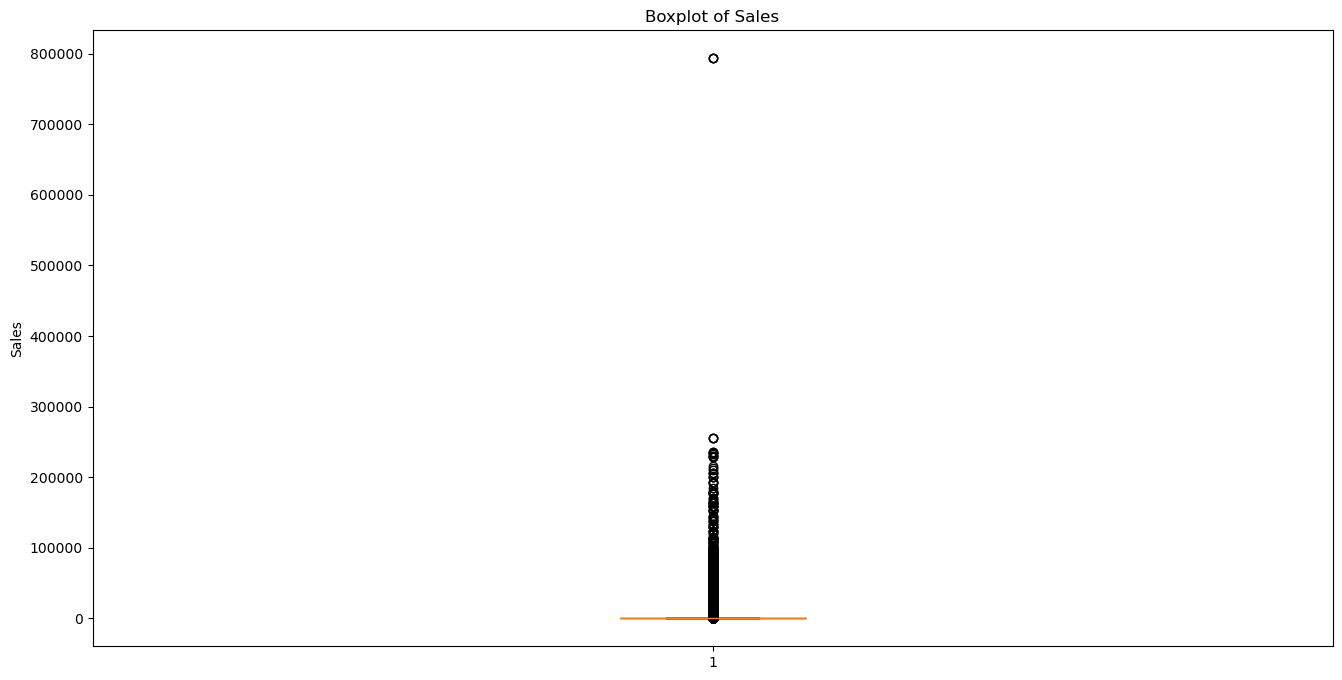

,sales_date,customer_district_code,item_type,sales
count,9.404680e+05,940468.000000,940468.000000,940468.000000
mean,2.019454e+07,385.358194,5.883835,461.023845
std,1.905844e+05,152.283711,1.848675,3153.040846
min,2.014030e+07,100.000000,1.000000,1.100000
25%,2.017101e+07,300.000000,5.000000,29.100000
50%,2.020101e+07,400.000000,7.000000,75.500000
75%,2.022101e+07,500.000000,7.000000,209.600000
max,2.027401e+08,720.000000,9.000000,793543.080000


In [64]:
# Create boxplots of sales column to identify outliers
plt.figure(figsize=(16, 8))
plt.boxplot(assessment['sales'], patch_artist=True)
plt.title('Boxplot of Sales')
plt.ylabel('Sales')
plt.show()

#Show the descriptive statistics of the dataset
assessment.describe()

In [65]:
#Grouping to find the median of sales for each item type and item type description
sales_median = assessment.groupby(['item_type','item_type_description'])['sales'].median().reset_index()
sales_median

,item_type,item_type_description,sales
0,1.0,Wall-mount,525.260
1,2.0,Industrial,224.265
2,3.0,Pendants,56.000
3,4.0,Solar,83.900
4,5.0,Landscape,71.100
5,6.0,Healthcare,86.100
6,7.0,Decorative,53.520
7,8.0,Road-and-street,97.040
8,9.0,Garage,106.850


In [66]:
# Filter dataframe to show only wall mount from the item type description 
filtered_sales_wm = assessment[assessment["item_type_description"].isin(['Wall-mount'])]
filtered_sales_wm

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
107,20191030.0,500.0,1.0,Wall-mount,817.10,Metro Electrical Distributors,MED,940,Traditional,T203,2019,10,30
615,20241025.0,300.0,1.0,Wall-mount,239.88,Next Gen Electrical Solutions,NES,COM,Traditional,T607,2024,10,25
1380,20211025.0,400.0,1.0,Wall-mount,269.70,Next Gen Electrical Solutions,NES,DLT,Traditional,T428,2021,10,25
1381,20221016.0,500.0,1.0,Wall-mount,883.10,Electra Corp Ltd,ELC,DLT,Traditional,T428,2022,10,16
1382,20221016.0,500.0,1.0,Wall-mount,1471.10,Electra Corp Ltd,ELC,DLT,Traditional,P347,2022,10,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...
951082,20171002.0,500.0,1.0,Wall-mount,1227.50,Nationwide Lighting Group,NLG,COM,Traditional,T909,2017,10,02
951150,20201030.0,600.0,1.0,Wall-mount,133.74,Next Gen Electrical Solutions,NES,SUR,Traditional,T222,2020,10,30
951166,20181017.0,600.0,1.0,Wall-mount,156.48,Nationwide Lighting Group,NLG,SUR,Traditional,T400,2018,10,17
951170,20181017.0,600.0,1.0,Wall-mount,156.48,Nationwide Lighting Group,NLG,SUR,Traditional,T432,2018,10,17


In [67]:
#caluclate 25th percentile of wall mount
percentile25_wm = filtered_sales_wm['sales'].quantile(0.25)
print('percentile25_wm ', percentile25_wm)

#caluclate 75th percentile of wall mount
percentile75_wm = filtered_sales_wm['sales'].quantile(0.75)
print('percentile75_wm ', percentile75_wm)

percentile25_wm  183.6125
percentile75_wm  1711.4675


In [68]:
#caluclate the median of sales of wall mount
median_sales_wm = filtered_sales_wm['sales'].median() 
print(median_sales_wm)

525.26


In [69]:
#Calculate interquartile range of wall mount
iqr_sales_wm = percentile75_wm - percentile25_wm
print(iqr_sales_wm)

#Calcualte upper and lower thresholds for outliers of wall mount
upper_limit_wm = percentile75_wm + 1.5 *iqr_sales_wm
lower_limit_wm = percentile25_wm - 1.5 *iqr_sales_wm

#Show upper and lower limit:
print ('Upper limit of wm is: ' + str(upper_limit_wm))
print ('Lower limit of wm is: ' + str(lower_limit_wm))

1527.855
Upper limit of wm is: 4003.25
Lower limit of wm is: -2108.17


In [70]:
#isolate outliers lower than the lower limit of wall mount
filtered_sales_wm[filtered_sales_wm['sales'] < lower_limit_wm]

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day


In [71]:
#isolate outliers higher than the upper limit of wall mount
df_upper_wm = filtered_sales_wm[filtered_sales_wm['sales'] > upper_limit_wm]
df_upper_wm

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
7591,20231031.0,300.0,1.0,Wall-mount,4186.10,Metro Electrical Distributors,MED,DLT,Accessories,R806,2023,10,31
11310,20201008.0,410.0,1.0,Wall-mount,13441.10,Next Gen Electrical Solutions,NES,DLT,Accessories,R806,2020,10,08
11978,20221029.0,400.0,1.0,Wall-mount,4964.65,Next Gen Electrical Solutions,NES,DLT,Traditional,R806,2022,10,29
12070,20221030.0,510.0,1.0,Wall-mount,5715.90,Bright Power Solutions,BPS,DLT,Traditional,R806,2022,10,30
14494,20201011.0,600.0,1.0,Wall-mount,6662.22,Electra Corp Ltd,ELC,DLT,Traditional,R806,2020,10,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
950791,20181017.0,200.0,1.0,Wall-mount,8893.10,General Suppliers Pty,ZZZ,RWY,Traditional,T400,2018,10,17
951033,20181031.0,300.0,1.0,Wall-mount,26857.10,Metro Electrical Distributors,MED,TRO,Traditional,T300,2018,10,31
951034,20181031.0,720.0,1.0,Wall-mount,10954.10,Inter Global Trading,INTERCO,TRO,Traditional,T408,2018,10,31
951077,20181030.0,500.0,1.0,Wall-mount,9901.10,Metro Electrical Distributors,MED,TRO,Traditional,T300,2018,10,30


In [72]:
#group the upper outliers wall mount to list 
outliers_wm_upper = df_upper_wm['sales'].tolist()
outliers_wm_upper

#fix the outliers by replacing them with median of wall mount
assessment['sales'].replace(outliers_wm_upper, median_sales_wm, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_22762/2091267032.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  assessment['sales'].replace(outliers_wm_upper, median_sales_wm, inplace=True)


In [73]:
# Filter dataframe to show only Industrial from the item type description 
filtered_sales_ind = assessment[assessment["item_type_description"].isin(['Industrial'])]
filtered_sales_ind

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
56223,20231002.0,210.0,2.0,Industrial,96.89,Unified Electrical Suppliers,UES,COM,Traditional,T612,2023,10,02
56269,20231024.0,500.0,2.0,Industrial,523.10,Metro Electrical Distributors,MED,COM,Traditional,P345,2023,10,24
56270,20211008.0,500.0,2.0,Industrial,285.70,Electra Corp Ltd,ELC,COM,Accessories,P415,2021,10,08
56271,20201028.0,500.0,2.0,Industrial,143.40,Electra Corp Ltd,ELC,COM,Traditional,P347,2020,10,28
56272,20231010.0,500.0,2.0,Industrial,214.55,Electra Corp Ltd,ELC,COM,Traditional,P342,2023,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
948583,20201021.0,720.0,2.0,Industrial,1441.10,Inter Global Trading,INTERCO,COM,Traditional,T432,2020,10,21
948595,20181010.0,720.0,2.0,Industrial,161.10,Inter Global Trading,INTERCO,COM,Traditional,T909,2018,10,10
948596,20201028.0,720.0,2.0,Industrial,161.10,Inter Global Trading,INTERCO,COM,Traditional,T228,2020,10,28
948597,20181008.0,720.0,2.0,Industrial,1601.10,Inter Global Trading,INTERCO,COM,Traditional,P347,2018,10,08


In [74]:
#caluclate 25th percentile of industrial
percentile25_ind = filtered_sales_ind['sales'].quantile(0.25)
print('percentile25_ind ', percentile25_ind)

#caluclate 75th percentile of industrial
percentile75_ind = filtered_sales_ind['sales'].quantile(0.75)
print('percentile75_ind ', percentile75_ind)

percentile25_ind  62.300000000000004
percentile75_ind  650.45


In [75]:
#caluclate the median of sales of industrial
median_sales_ind = filtered_sales_ind['sales'].median() 
print(median_sales_ind)

224.265


In [76]:
#Calculate interquartile range of industrial
iqr_sales_ind = percentile75_ind - percentile25_ind
print(iqr_sales_ind)

#Calcualte upper and lower thresholds for outliers of industrial
upper_limit_ind = percentile75_ind + 1.5 *iqr_sales_ind
lower_limit_ind = percentile25_ind - 1.5 *iqr_sales_ind

#Show upper and lower limit:
print ('Upper limit of wm is: ' + str(upper_limit_ind))
print ('Lower limit of wm is: ' + str(lower_limit_ind))

588.1500000000001
Upper limit of wm is: 1532.6750000000002
Lower limit of wm is: -819.9250000000002


In [77]:
#isolate outliers lower than the lower limit of industrial
filtered_sales_ind[filtered_sales_ind['sales'] < lower_limit_ind]

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day


In [78]:
#isolate outliers higher than the upper limit of industrial
df_upper_ind = filtered_sales_ind[filtered_sales_ind['sales'] > upper_limit_ind]
df_upper_ind

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
66663,20211018.0,720.0,2.0,Industrial,5331.98,Inter Global Trading,INTERCO,SUR,LED,P345,2021,10,18
122494,20201008.0,720.0,2.0,Industrial,2323.10,Inter Global Trading,INTERCO,SUR,Traditional,T215,2020,10,08
126426,20221016.0,500.0,2.0,Industrial,1815.50,End Users Solutions,ZZ8,COM,Traditional,P342,2022,10,16
128091,20201020.0,300.0,2.0,Industrial,4962.84,Independent Retailers Association,ZZ2,COM,Traditional,P415,2020,10,20
128092,20231029.0,300.0,2.0,Industrial,3746.38,Independent Retailers Association,ZZ2,COM,Traditional,T215,2023,10,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
920035,20171004.0,720.0,2.0,Industrial,2765.90,Inter Global Trading,INTERCO,COM,Traditional,T225,2017,10,04
921959,20161022.0,510.0,2.0,Industrial,1639.10,Bright Power Solutions,BPS,COM,Traditional,P506,2016,10,22
947946,20181026.0,720.0,2.0,Industrial,1651.46,Inter Global Trading,INTERCO,COM,Traditional,P237,2018,10,26
948597,20181008.0,720.0,2.0,Industrial,1601.10,Inter Global Trading,INTERCO,COM,Traditional,P347,2018,10,08


In [79]:
#group the upper outliers of industrial to list  
outliers_ind_upper = df_upper_ind['sales'].tolist()
outliers_ind_upper

#fix the outliers by replacing them with median of industrial
assessment['sales'].replace(outliers_ind_upper, median_sales_ind, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_22762/3158067814.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  assessment['sales'].replace(outliers_ind_upper, median_sales_ind, inplace=True)


In [80]:
# Filter dataframe to show only Pendants from the item type description
filtered_sales_pd = assessment[assessment["item_type_description"].isin(['Pendants'])]
filtered_sales_pd

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
106741,20191024.0,720.0,3.0,Pendants,7361.50,Inter Global Trading,INTERCO,FLD,LED,T504,2019,10,24
106742,20201028.0,540.0,3.0,Pendants,28920.10,Power Hub Distribution,Z4500,FLD,LED,P344,2020,10,28
131144,20211005.0,535.0,3.0,Pendants,21.82,Power Hub Distribution,Z4500,COM,Traditional,T603,2021,10,05
131145,20231024.0,540.0,3.0,Pendants,20.27,Russell & Partners Electric,Z4000,COM,Traditional,T602,2023,10,24
131146,20201028.0,530.0,3.0,Pendants,20.27,Russell & Partners Electric,Z4000,COM,Traditional,T603,2020,10,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
943395,20151006.0,520.0,3.0,Pendants,1.10,Inlite NZ Ltd,ZI900,HLB,Traditional,T229,2015,10,06
947949,20151006.0,720.0,3.0,Pendants,1.26,Inter Global Trading,INTERCO,SAE,Traditional,P344,2015,10,06
950720,20161031.0,530.0,3.0,Pendants,33.70,Ideal Electrical Solutions,Z2000,SUR,Traditional,T408,2016,10,31
950951,20141024.0,520.0,3.0,Pendants,683.11,Inlite Solutions,ZI800,COM,Traditional,P342,2014,10,24


In [81]:
#caluclate 25th percentile of pendants
percentile25_pd = filtered_sales_pd['sales'].quantile(0.25)
print('percentile25_pd ', percentile25_pd)

#caluclate 75th percentile of pendants
percentile75_pd = filtered_sales_pd['sales'].quantile(0.75)
print('percentile75_pd ', percentile75_pd)

percentile25_pd  19.700000000000003
percentile75_pd  192.98


In [82]:
#caluclate the median of sales of pendants
median_sales_pd = filtered_sales_pd['sales'].median() 
print(median_sales_pd)

56.0


In [83]:
#Calculate interquartile range of pendants
iqr_sales_pd = percentile75_pd - percentile25_pd
print(iqr_sales_pd)

#Calcualte upper and lower thresholds for outliers of pendants
upper_limit_pd = percentile75_pd + 1.5 *iqr_sales_pd
lower_limit_pd = percentile25_pd - 1.5 *iqr_sales_pd

#Show upper and lower limit:
print ('Upper limit of pd is: ' + str(upper_limit_pd))
print ('Lower limit of pd is: ' + str(lower_limit_pd))

173.27999999999997
Upper limit of pd is: 452.9
Lower limit of pd is: -240.21999999999997


In [84]:
#isolate outliers lower than the lower limit of pendants
filtered_sales_pd[filtered_sales_pd['sales'] < lower_limit_pd]

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day


In [85]:
#isolate outliers higher than the upper limit of pendants
df_upper_pd = filtered_sales_pd[filtered_sales_pd['sales'] > upper_limit_pd]
df_upper_pd

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
106741,20191024.0,720.0,3.0,Pendants,7361.50,Inter Global Trading,INTERCO,FLD,LED,T504,2019,10,24
106742,20201028.0,540.0,3.0,Pendants,28920.10,Power Hub Distribution,Z4500,FLD,LED,P344,2020,10,28
137496,20221004.0,300.0,3.0,Pendants,907.88,Nationwide Lighting Group,NLG,COM,Traditional,T431,2022,10,04
137500,20201005.0,720.0,3.0,Pendants,650.75,Inter Global Trading,INTERCO,COM,Traditional,T306,2020,10,05
137530,20201006.0,720.0,3.0,Pendants,4138.98,Inter Global Trading,INTERCO,DLT,Accessories,P345,2020,10,06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
939936,20181008.0,400.0,3.0,Pendants,469.15,Metro Electrical Distributors,MED,SUR,Traditional,T215,2018,10,08
943217,20141024.0,520.0,3.0,Pendants,5457.56,Inlite Solutions,ZI800,COM,Traditional,P342,2014,10,24
943365,20171002.0,500.0,3.0,Pendants,618.60,Metro Electrical Distributors,MED,SUR,Traditional,T909,2017,10,02
943366,20181023.0,500.0,3.0,Pendants,618.60,Metro Electrical Distributors,MED,SUR,Traditional,T607,2018,10,23


In [86]:
#group the upper outliers of pendants to list 
outliers_pd_upper = df_upper_pd['sales'].tolist()
outliers_pd_upper

#fix the outliers by replacing them with median of pendants
assessment['sales'].replace(outliers_pd_upper, median_sales_pd, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_22762/3298562437.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  assessment['sales'].replace(outliers_pd_upper, median_sales_pd, inplace=True)


In [87]:
# Filter dataframe to show only Solar from the item type description
filtered_sales_sl = assessment[assessment["item_type_description"].isin(['Solar'])]
filtered_sales_sl

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
117,20221015.0,200.0,4.0,Solar,5795.30,Metro Electrical Distributors,MED,COM,Traditional,P345,2022,10,15
118,20201027.0,400.0,4.0,Solar,1453.81,Next Gen Electrical Solutions,NES,COM,Traditional,T203,2020,10,27
119,20221022.0,200.0,4.0,Solar,2303.20,Metro Electrical Distributors,MED,COM,Traditional,P344,2022,10,22
120,20221024.0,210.0,4.0,Solar,699.52,Aussie Energy Group,AEG,COM,Traditional,P344,2022,10,24
121,20191009.0,300.0,4.0,Solar,527.85,Bright Power Solutions,BPS,COM,Traditional,P342,2019,10,09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
948590,20171018.0,300.0,4.0,Solar,19.50,Nationwide Lighting Group,NLG,SUR,Traditional,T909,2017,10,18
948592,20151022.0,400.0,4.0,Solar,1.10,Electra Corp Ltd,ELC,FLD,Traditional,T909,2015,10,22
950929,20201023.0,600.0,4.0,Solar,14.20,Power Tools Direct,PTD,OTH,Traditional,P248,2020,10,23
951083,20171005.0,500.0,4.0,Solar,164.85,Global Electric Wholesalers,GEW,OTH,Traditional,P248,2017,10,05


In [88]:
#caluclate 25th percentile of solar
percentile25_sl = filtered_sales_sl['sales'].quantile(0.25)
print('percentile25_sl ', percentile25_sl)

#caluclate 75th percentile of solar
percentile75_sl = filtered_sales_sl['sales'].quantile(0.75)
print('percentile75_sl ', percentile75_sl)

percentile25_sl  27.900000000000002
percentile75_sl  232.005


In [89]:
#caluclate the median of sales of solar
median_sales_sl = filtered_sales_sl['sales'].median() 
print(median_sales_sl)

81.07


In [90]:
#Calculate interquartile range of solar
iqr_sales_sl = percentile75_sl - percentile25_sl
print(iqr_sales_sl)

#Calcualte upper and lower thresholds for outliers of solar
upper_limit_sl = percentile75_sl + 1.5 *iqr_sales_sl
lower_limit_sl = percentile25_sl - 1.5 *iqr_sales_sl

#Show upper and lower limit:
print ('Upper limit of sl is: ' + str(upper_limit_sl))
print ('Lower limit of sl is: ' + str(lower_limit_sl))

204.105
Upper limit of sl is: 538.1624999999999
Lower limit of sl is: -278.2575


In [91]:
#isolate outliers lower than the lower limit of solar
filtered_sales_sl[filtered_sales_sl['sales'] < lower_limit_sl]

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day


In [92]:
#isolate outliers higher than the upper limit of solar
df_upper_sl = filtered_sales_sl[filtered_sales_sl['sales'] > upper_limit_sl]
df_upper_sl

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
117,20221015.0,200.0,4.0,Solar,5795.30,Metro Electrical Distributors,MED,COM,Traditional,P345,2022,10,15
118,20201027.0,400.0,4.0,Solar,1453.81,Next Gen Electrical Solutions,NES,COM,Traditional,T203,2020,10,27
119,20221022.0,200.0,4.0,Solar,2303.20,Metro Electrical Distributors,MED,COM,Traditional,P344,2022,10,22
120,20221024.0,210.0,4.0,Solar,699.52,Aussie Energy Group,AEG,COM,Traditional,P344,2022,10,24
122,20221015.0,400.0,4.0,Solar,1453.82,General Suppliers Pty,ZZZ,COM,Traditional,P345,2022,10,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
939586,20171012.0,720.0,4.0,Solar,659.23,Inter Global Trading,INTERCO,COM,LED,T504,2017,10,12
939633,20151025.0,720.0,4.0,Solar,940.74,Inter Global Trading,INTERCO,COM,Traditional,P345,2015,10,25
939663,20141019.0,210.0,4.0,Solar,2321.10,Nationwide Lighting Group,NLG,COM,Traditional,T612,2014,10,19
943135,20201007.0,520.0,4.0,Solar,644.63,Inlite NZ Ltd,ZI900,COM,Traditional,T909,2020,10,07


In [93]:
#group the upper outliers of solar to list 
outliers_sl_upper = df_upper_sl['sales'].tolist()
outliers_sl_upper

#fix the outliers by replacing them with median of solar
assessment['sales'].replace(outliers_sl_upper, median_sales_sl, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_22762/3696021751.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  assessment['sales'].replace(outliers_sl_upper, median_sales_sl, inplace=True)


In [94]:
# Filter dataframe to show only Healthcare from the item type description
filtered_sales_hc = assessment[assessment["item_type_description"].isin(['Healthcare'])]
filtered_sales_hc

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
78,20201025.0,720.0,6.0,Healthcare,315.44,Inter Global Trading,INTERCO,PEN,Traditional,P347,2020,10,25
79,20191018.0,720.0,6.0,Healthcare,315.44,Inter Global Trading,INTERCO,PEN,Traditional,P342,2019,10,18
80,20211007.0,300.0,6.0,Healthcare,81.07,Metro Electrical Distributors,MED,PEN,Traditional,P347,2021,10,07
81,20221029.0,720.0,6.0,Healthcare,1298.14,Inter Global Trading,INTERCO,COM,Traditional,P344,2022,10,29
82,20191015.0,400.0,6.0,Healthcare,2394.68,Nationwide Lighting Group,NLG,COM,Traditional,P344,2019,10,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...
951134,20181004.0,500.0,6.0,Healthcare,81.07,Metro Electrical Distributors,MED,FLD,Traditional,T226,2018,10,04
951152,20141010.0,200.0,6.0,Healthcare,275.60,Aussie Energy Group,AEG,SUR,Traditional,P300,2014,10,10
951153,20161024.0,540.0,6.0,Healthcare,42.35,Russell & Partners Electric,Z4000,LMP,Traditional,T215,2016,10,24
951158,20181009.0,500.0,6.0,Healthcare,937.10,Metro Electrical Distributors,MED,FLD,Traditional,T612,2018,10,09


In [95]:
#caluclate 25th percentile of healthcare
percentile25_hc = filtered_sales_hc['sales'].quantile(0.25)
print('percentile25_hc ', percentile25_hc)

#caluclate 75th percentile of healthcare
percentile75_hc = filtered_sales_hc['sales'].quantile(0.75)
print('percentile75_hc ', percentile75_hc)

percentile25_hc  36.6
percentile75_hc  201.1


In [96]:
#caluclate the median of sales of healthcare
median_sales_hc = filtered_sales_hc['sales'].median() 
print(median_sales_hc)

81.07


In [97]:
#Calculate interquartile range of healthcare
iqr_sales_hc = percentile75_hc - percentile25_hc
print(iqr_sales_hc)

#Calcualte upper and lower thresholds for outliers of healthcare
upper_limit_hc = percentile75_hc + 1.5 *iqr_sales_hc
lower_limit_hc = percentile25_hc - 1.5 *iqr_sales_hc

#Show upper and lower limit:
print ('Upper limit of hc is: ' + str(upper_limit_hc))
print ('Lower limit of hc is: ' + str(lower_limit_hc))

164.5
Upper limit of hc is: 447.85
Lower limit of hc is: -210.15


In [98]:
#isolate outliers lower than the lower limit of healthcare
filtered_sales_hc[filtered_sales_hc['sales'] < lower_limit_hc]

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day


In [99]:
#isolate outliers higher than the upper limit of healthcare
df_upper_hc = filtered_sales_hc[filtered_sales_hc['sales'] > upper_limit_hc]
df_upper_hc

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
81,20221029.0,720.0,6.0,Healthcare,1298.14,Inter Global Trading,INTERCO,COM,Traditional,P344,2022,10,29
82,20191015.0,400.0,6.0,Healthcare,2394.68,Nationwide Lighting Group,NLG,COM,Traditional,P344,2019,10,15
83,20231002.0,300.0,6.0,Healthcare,2441.10,Bright Power Solutions,BPS,COM,Traditional,P344,2023,10,02
84,20241012.0,200.0,6.0,Healthcare,1071.46,General Suppliers Pty,ZZZ,COM,Traditional,P344,2024,10,12
87,20191018.0,720.0,6.0,Healthcare,991.66,Inter Global Trading,INTERCO,COM,Traditional,T203,2019,10,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...
951024,20141011.0,520.0,6.0,Healthcare,1172.72,Inlite Solutions,ZI800,COM,Traditional,T204,2014,10,11
951036,20171024.0,540.0,6.0,Healthcare,2458.10,Independent Traders Ltd,Z8500,COM,Traditional,P237,2017,10,24
951085,20151007.0,600.0,6.0,Healthcare,2306.90,Metro Electrical Distributors,MED,SUR,Traditional,T408,2015,10,07
951094,20141013.0,200.0,6.0,Healthcare,714.80,Next Gen Electrical Solutions,NES,SUR,Traditional,T215,2014,10,13


In [100]:
#group the upper outliers of healthcare to list 
outliers_hc_upper = df_upper_hc['sales'].tolist()
outliers_hc_upper

#fix the outliers by replacing them with median of healthcare
assessment['sales'].replace(outliers_hc_upper, median_sales_hc, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_22762/93144804.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  assessment['sales'].replace(outliers_hc_upper, median_sales_hc, inplace=True)


In [101]:
# Filter dataframe to show only Decorative from the item type description
filtered_sales_decor = assessment[assessment["item_type_description"].isin(['Decorative'])]
filtered_sales_decor

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
9,20221010.0,400.0,7.0,Decorative,2571.07,Metro Electrical Distributors,MED,SUR,Traditional,P342,2022,10,10
10,20211026.0,500.0,7.0,Decorative,3.44,Independent Retailers Association,ZZ2,LMP,Traditional,P344,2021,10,26
11,20211008.0,200.0,7.0,Decorative,6.30,Nationwide Lighting Group,NLG,LMP,Traditional,T408,2021,10,08
12,20211015.0,200.0,7.0,Decorative,6.30,Independent Retailers Association,ZZ2,LMP,Traditional,T408,2021,10,15
13,20191007.0,200.0,7.0,Decorative,3.70,Independent Retailers Association,ZZ2,LMP,Traditional,P237,2019,10,07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
951149,20161018.0,500.0,7.0,Decorative,174.10,Metro Electrical Distributors,MED,SUR,Traditional,T501,2016,10,18
951151,20151013.0,410.0,7.0,Decorative,19.10,Metro Electrical Distributors,MED,SUR,Traditional,T222,2015,10,13
951154,20151029.0,200.0,7.0,Decorative,147.35,General Suppliers Pty,ZZZ,LMP,Traditional,T224,2015,10,29
951155,20151022.0,200.0,7.0,Decorative,1.10,Pro Lighting Specialists,ZZ3,LMP,Traditional,P342,2015,10,22


In [102]:
#caluclate 25th percentile of Decorative
percentile25_decor = filtered_sales_decor['sales'].quantile(0.25)
print('percentile25_decor ', percentile25_decor)

#caluclate 75th percentile of Decorative
percentile75_decor = filtered_sales_decor['sales'].quantile(0.75)
print('percentile75_decor ', percentile75_decor)

percentile25_decor  22.240000000000002
percentile75_decor  114.75


In [103]:
#caluclate the median of sales of Decorative
median_sales_decor = filtered_sales_decor['sales'].median() 
print(median_sales_decor)

53.52


In [104]:
#Calculate interquartile range of Decorative
iqr_sales_decor = percentile75_decor - percentile25_decor
print(iqr_sales_decor)

#Calcualte upper and lower thresholds for outliers of Decorative
upper_limit_decor = percentile75_decor + 1.5 *iqr_sales_decor
lower_limit_decor = percentile25_decor - 1.5 *iqr_sales_decor

#Show upper and lower limit:
print ('Upper limit of decor is: ' + str(upper_limit_decor))
print ('Lower limit of decor is: ' + str(lower_limit_decor))

92.50999999999999
Upper limit of decor is: 253.515
Lower limit of decor is: -116.52499999999998


In [105]:
#isolate outliers lower than the lower limit of Decorative
filtered_sales_decor[filtered_sales_decor['sales'] < lower_limit_decor]

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day


In [106]:
#isolate outliers higher than the upper limit of Decorative
df_upper_decor = filtered_sales_decor[filtered_sales_decor['sales'] > upper_limit_decor]
df_upper_decor

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
9,20221010.0,400.0,7.0,Decorative,2571.07,Metro Electrical Distributors,MED,SUR,Traditional,P342,2022,10,10
318,20201007.0,410.0,7.0,Decorative,301.10,Metro Electrical Distributors,MED,LMP,Traditional,T432,2020,10,07
705,20211022.0,410.0,7.0,Decorative,261.10,Builders Supply Network,ZZ1,LMP,Traditional,T203,2021,10,22
2071,20201005.0,300.0,7.0,Decorative,274.85,Nationwide Lighting Group,NLG,LMP,Traditional,T607,2020,10,05
2203,20221016.0,300.0,7.0,Decorative,366.10,Nationwide Lighting Group,NLG,LMP,Traditional,T200,2022,10,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...
951001,20141005.0,300.0,7.0,Decorative,287.30,Metro Electrical Distributors,MED,LMP,Traditional,T400,2014,10,05
951029,20181003.0,540.0,7.0,Decorative,392.10,Independent Traders Ltd,Z8500,LMP,Traditional,T215,2018,10,03
951030,20181005.0,200.0,7.0,Decorative,401.10,Aussie Energy Group,AEG,LMP,Traditional,T203,2018,10,05
951068,20171002.0,600.0,7.0,Decorative,758.10,Next Gen Electrical Solutions,NES,SUR,Traditional,T300,2017,10,02


In [107]:
#group the upper outliers of decorative to list 
outliers_decor_upper = df_upper_decor['sales'].tolist()
outliers_decor_upper

#fix the outliers by replacing them with median of Decorative
assessment['sales'].replace(outliers_decor_upper, median_sales_decor, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_22762/2853411130.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  assessment['sales'].replace(outliers_decor_upper, median_sales_decor, inplace=True)


In [108]:
# Filter dataframe to show only Road-and-street from the item type description
filtered_sales_RS = assessment[assessment["item_type_description"].isin(['Road-and-street'])]
filtered_sales_RS

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
36894,20201004.0,720.0,8.0,Road-and-street,53.52,Inter Global Trading,INTERCO,SUR,Traditional,T431,2020,10,04
36895,20231010.0,720.0,8.0,Road-and-street,1143.10,Inter Global Trading,INTERCO,SUR,Traditional,T428,2023,10,10
116420,20241027.0,200.0,8.0,Road-and-street,58.43,Unified Electrical Suppliers,UES,COM,LED,P515,2024,10,27
116421,20241013.0,210.0,8.0,Road-and-street,58.43,Electra Corp Ltd,ELC,COM,Accessories,P342,2024,10,13
116422,20241006.0,200.0,8.0,Road-and-street,81.07,Next Gen Electrical Solutions,NES,COM,Traditional,T504,2024,10,06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
943296,20151020.0,500.0,8.0,Road-and-street,63.96,Metro Electrical Distributors,MED,COM,Traditional,P350,2015,10,20
943376,20171016.0,500.0,8.0,Road-and-street,163.10,Metro Electrical Distributors,MED,COM,Traditional,T203,2017,10,16
943383,20201029.0,500.0,8.0,Road-and-street,211.10,Metro Electrical Distributors,MED,COM,Traditional,T400,2020,10,29
943388,20181024.0,500.0,8.0,Road-and-street,71.10,Metro Electrical Distributors,MED,COM,Traditional,P500,2018,10,24


In [109]:
#caluclate 25th percentile of Road-and-street
percentile25_RS = filtered_sales_RS['sales'].quantile(0.25)
print('percentile25_RS ', percentile25_RS)

#caluclate 75th percentile of Road-and-street
percentile75_RS = filtered_sales_RS['sales'].quantile(0.75)
print('percentile75_RS ', percentile75_RS)

percentile25_RS  31.205000000000002
percentile75_RS  145.5825


In [110]:
#caluclate the median of sales of Road-and-street
median_sales_RS = filtered_sales_RS['sales'].median() 
print(median_sales_RS)

64.42999999999999


In [111]:
#Calculate interquartile range of Road-and-street
iqr_sales_RS = percentile75_RS - percentile25_RS
print(iqr_sales_RS)

#Calcualte upper and lower thresholds for outliers of Road-and-street
upper_limit_RS = percentile75_RS + 1.5 *iqr_sales_RS
lower_limit_RS = percentile25_RS - 1.5 *iqr_sales_RS

#Show upper and lower limit:
print ('Upper limit of RS is: ' + str(upper_limit_RS))
print ('Lower limit of RS is: ' + str(lower_limit_RS))

114.37750000000001
Upper limit of RS is: 317.14875000000006
Lower limit of RS is: -140.36125


In [112]:
#isolate outliers lower than the lower limit of Road-and-street
filtered_sales_RS[filtered_sales_RS['sales'] < lower_limit_RS]

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day


In [113]:
#isolate outliers higher than the upper limit of Road-and-street
df_upper_RS = filtered_sales_RS[filtered_sales_RS['sales'] > upper_limit_RS]
df_upper_RS

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
36895,20231010.0,720.0,8.0,Road-and-street,1143.10,Inter Global Trading,INTERCO,SUR,Traditional,T428,2023,10,10
138356,20231008.0,720.0,8.0,Road-and-street,2971.40,Inter Global Trading,INTERCO,COM,Accessories,P344,2023,10,08
138357,20201004.0,710.0,8.0,Road-and-street,7129.81,General Suppliers Pty,ZZZ,COM,Traditional,P344,2020,10,04
138358,20211022.0,710.0,8.0,Road-and-street,7129.81,General Suppliers Pty,ZZZ,COM,Accessories,P342,2021,10,22
138395,20201025.0,710.0,8.0,Road-and-street,42773.38,General Suppliers Pty,ZZZ,COM,Traditional,T408,2020,10,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...
940575,20141002.0,720.0,8.0,Road-and-street,318.20,Inter Global Trading,INTERCO,COM,Accessories,T909,2014,10,02
940591,20171019.0,210.0,8.0,Road-and-street,1064.25,Metro Electrical Distributors,MED,COM,Accessories,T612,2017,10,19
940593,20201015.0,720.0,8.0,Road-and-street,1973.90,Inter Global Trading,INTERCO,COM,LED,P248,2020,10,15
940606,20171010.0,200.0,8.0,Road-and-street,1147.46,Aussie Energy Group,AEG,COM,Traditional,T400,2017,10,10


In [114]:
#group the upper outliers of road and street to list 
outliers_RS_upper = df_upper_RS['sales'].tolist()
outliers_RS_upper

#fix the outliers by replacing them with median of Road-and-street
assessment['sales'].replace(outliers_RS_upper, median_sales_RS, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_22762/1904567750.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  assessment['sales'].replace(outliers_RS_upper, median_sales_RS, inplace=True)


In [115]:
# Filter dataframe to show only Garage from the item type description
filtered_sales_g = assessment[assessment["item_type_description"].isin(['Garage'])]
filtered_sales_g

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
8988,20191030.0,600.0,9.0,Garage,81.07,Metro Electrical Distributors,MED,COM,Traditional,R806,2019,10,30
8989,20231030.0,200.0,9.0,Garage,161.10,Metro Electrical Distributors,MED,COM,Traditional,R806,2023,10,30
8990,20221005.0,500.0,9.0,Garage,147.62,Independent Retailers Association,ZZ2,COM,Traditional,R806,2022,10,05
8991,20191014.0,200.0,9.0,Garage,41.80,Aussie Energy Group,AEG,COM,Traditional,R806,2019,10,14
8992,20201012.0,200.0,9.0,Garage,82.50,Aussie Energy Group,AEG,COM,Traditional,R806,2020,10,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
946253,20141017.0,200.0,9.0,Garage,81.07,Metro Electrical Distributors,MED,COM,Traditional,P347,2014,10,17
946255,20141017.0,500.0,9.0,Garage,1107.34,Metro Electrical Distributors,MED,COM,Traditional,T408,2014,10,17
946256,20201019.0,500.0,9.0,Garage,70.80,Electra Corp Ltd,ELC,COM,Traditional,T408,2020,10,19
947906,20161008.0,720.0,9.0,Garage,8.58,Inter Global Trading,INTERCO,COM,Traditional,T432,2016,10,08


In [116]:
#caluclate 25th percentile of garage
percentile25_g = filtered_sales_g['sales'].quantile(0.25)
print('percentile25_g ', percentile25_g)

#caluclate 75th percentile of garage
percentile75_g = filtered_sales_g['sales'].quantile(0.75)
print('percentile75_g ', percentile75_g)

percentile25_g  53.52
percentile75_g  149.9


In [117]:
#caluclate the median of sales of garage
median_sales_g = filtered_sales_g['sales'].median() 
print(median_sales_g)

83.5


In [118]:
#Calculate interquartile range of garage
iqr_sales_g = percentile75_RS - percentile25_g
print(iqr_sales_g)

#Calcualte upper and lower thresholds for outliers of garage
upper_limit_g = percentile75_g + 1.5 *iqr_sales_g
lower_limit_g = percentile25_g - 1.5 *iqr_sales_g

#Show upper and lower limit:
print ('Upper limit of Garage is: ' + str(upper_limit_g))
print ('Lower limit of Garage is: ' + str(lower_limit_g))

92.0625
Upper limit of Garage is: 287.99375
Lower limit of Garage is: -84.57374999999999


In [119]:
#isolate outliers lower than the lower limit of garage
filtered_sales_g[filtered_sales_g['sales'] < lower_limit_g]

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day


In [120]:
#isolate outliers higher than the upper limit of garage
df_upper_g = filtered_sales_g[filtered_sales_g['sales'] > upper_limit_g]
df_upper_g

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
8999,20191025.0,410.0,9.0,Garage,652.30,Next Gen Electrical Solutions,NES,COM,Traditional,R806,2019,10,25
10237,20191021.0,210.0,9.0,Garage,367.60,Metro Electrical Distributors,MED,COM,Traditional,R806,2019,10,21
19974,20201014.0,200.0,9.0,Garage,581.06,Builders Supply Network,ZZ1,COM,Traditional,R806,2020,10,14
19984,20241005.0,200.0,9.0,Garage,387.74,Builders Supply Network,ZZ1,COM,Traditional,R806,2024,10,05
19985,20221024.0,200.0,9.0,Garage,387.74,Builders Supply Network,ZZ1,COM,Traditional,R806,2022,10,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...
942057,20201019.0,600.0,9.0,Garage,829.85,Independent Retailers Association,ZZ2,COM,Traditional,T300,2020,10,19
942058,20151028.0,600.0,9.0,Garage,732.86,Nationwide Lighting Group,NLG,COM,Traditional,P344,2015,10,28
943102,20151015.0,540.0,9.0,Garage,2521.50,Independent Traders Ltd,Z8500,COM,Accessories,T300,2015,10,15
946237,20171027.0,200.0,9.0,Garage,346.80,Metro Electrical Distributors,MED,COM,Traditional,T428,2017,10,27


In [121]:
#group the upper outliers of garage to list  
outliers_g_upper = df_upper_g['sales'].tolist()
outliers_g_upper

#fix the outliers by replacing them with median of garage
assessment['sales'].replace(outliers_g_upper, median_sales_g, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_22762/3164078968.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  assessment['sales'].replace(outliers_g_upper, median_sales_g, inplace=True)


In [122]:
# Filter dataframe to show only Landscape from the item type description
filtered_sales_ls = assessment[assessment["item_type_description"].isin(['Landscape'])]
filtered_sales_ls

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
0,20191025.0,400.0,5.0,Landscape,3.33,Metro Electrical Distributors,MED,COM,Traditional,T612,2019,10,25
1,20231013.0,200.0,5.0,Landscape,3.58,Aussie Energy Group,AEG,COM,Traditional,P345,2023,10,13
2,20241011.0,200.0,5.0,Landscape,54.50,Next Gen Electrical Solutions,NES,OTH,Traditional,P345,2024,10,11
3,20191011.0,200.0,5.0,Landscape,26.00,Metro Electrical Distributors,MED,OTH,Traditional,T504,2019,10,11
4,20211021.0,400.0,5.0,Landscape,46.10,Metro Electrical Distributors,MED,COM,Traditional,T504,2021,10,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
951169,20171013.0,500.0,5.0,Landscape,38.54,Global Electric Wholesalers,GEW,SUR,Accessories,T602,2017,10,13
951171,20151006.0,500.0,5.0,Landscape,75.98,Global Electric Wholesalers,GEW,SUR,Accessories,P248,2015,10,06
951172,20151006.0,200.0,5.0,Landscape,245.10,Metro Electrical Distributors,MED,SUR,Traditional,T400,2015,10,06
951175,20151001.0,500.0,5.0,Landscape,32.10,Global Electric Wholesalers,GEW,SUR,Traditional,T226,2015,10,01


In [123]:
#caluclate 25th percentile of landscape
percentile25_ls = filtered_sales_ls['sales'].quantile(0.25)
print('percentile25_ls ', percentile25_ls)

#caluclate 75th percentile of landscape
percentile75_ls = filtered_sales_ls['sales'].quantile(0.75)
print('percentile75_ls ', percentile75_ls)

percentile25_ls  29.450000000000003
percentile75_ls  101.6


In [124]:
#Calculate interquartile range of landscape
iqr_sales_ls = percentile75_ls - percentile25_ls
print(iqr_sales_ls)

#Calcualte upper and lower thresholds for outliers of landscape
upper_limit_ls = percentile75_ls + 1.5 *iqr_sales_ls
lower_limit_ls = percentile25_ls - 1.5 *iqr_sales_ls

#Show upper and lower limit:
print ('Upper limit of ls is: ' + str(upper_limit_ls))
print ('Lower limit of ls is: ' + str(lower_limit_ls))

72.14999999999999
Upper limit of ls is: 209.825
Lower limit of ls is: -78.77499999999999


In [125]:
#caluclate the median of sales of landscape
median_sales_ls = filtered_sales_ls['sales'].median() 
print(median_sales_ls)

56.0


In [126]:
#isolate outliers lower than the lower limit of landscape
filtered_sales_ls[filtered_sales_ls['sales'] < lower_limit_ls]

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day


In [127]:
#isolate outliers higher than the upper limit of landscape
df_upper_ls = filtered_sales_ls[filtered_sales_ls['sales'] > upper_limit_ls]
df_upper_ls

,sales_date,customer_district_code,item_type,item_type_description,sales,business_chain_name,business_chain_code,business_area_code,light_source,salesperson_code,sales_year,sales_month,sales_day
549,20211011.0,400.0,5.0,Landscape,1999.70,Metro Electrical Distributors,MED,COM,Traditional,P345,2021,10,11
815,20191008.0,200.0,5.0,Landscape,1519.85,Electra Corp Ltd,ELC,COM,Traditional,T606,2019,10,08
857,20231030.0,200.0,5.0,Landscape,321.70,Next Gen Electrical Solutions,NES,COM,Traditional,P342,2023,10,30
1212,20201019.0,200.0,5.0,Landscape,231.90,Next Gen Electrical Solutions,NES,COM,Traditional,T400,2020,10,19
1345,20241020.0,400.0,5.0,Landscape,226.10,General Suppliers Pty,ZZZ,LMP,Traditional,P342,2024,10,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
950856,20141016.0,530.0,5.0,Landscape,2311.90,Power Hub Distribution,Z4500,SAE,Traditional,P225,2014,10,16
950928,20141017.0,410.0,5.0,Landscape,534.60,Aussie Energy Group,AEG,COM,Traditional,P248,2014,10,17
950934,20151007.0,540.0,5.0,Landscape,1051.44,Russell & Partners Electric,Z4000,SAE,Traditional,P345,2015,10,07
950935,20161017.0,540.0,5.0,Landscape,1579.58,Russell & Partners Electric,Z4000,SAE,LED,P344,2016,10,17


In [128]:
#group the upper outliers of landscape to list
outliers_ls_upper = df_upper_ls['sales'].tolist()
outliers_ls_upper

#fix the outliers by replacing them with median of landscape
assessment['sales'].replace(outliers_ls_upper, median_sales_ls, inplace=True)

/var/folders/b1/2lz6ssmx4n52cww0tsc3hhg80000gn/T/ipykernel_22762/3103543041.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  assessment['sales'].replace(outliers_ls_upper, median_sales_ls, inplace=True)


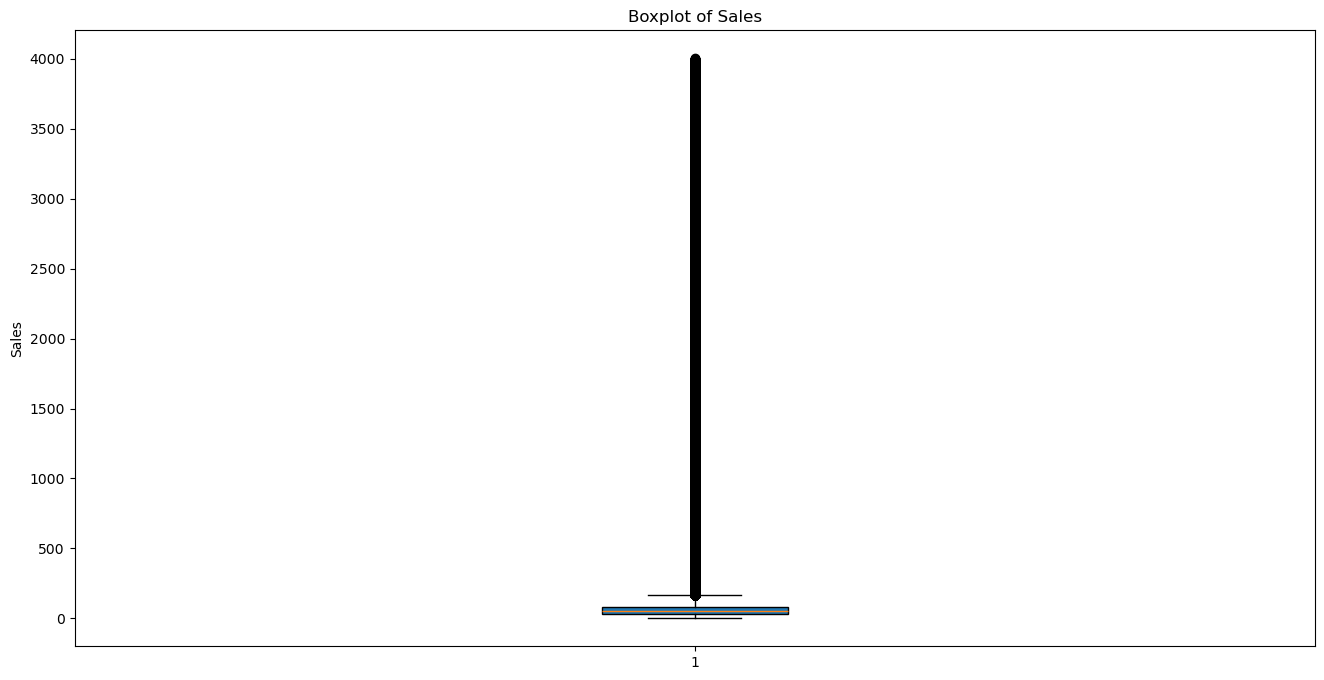

,sales_date,customer_district_code,item_type,sales
count,9.404680e+05,940468.000000,940468.000000,940468.000000
mean,2.019454e+07,385.358194,5.883835,97.567557
std,1.905844e+05,152.283711,1.848675,262.795100
min,2.014030e+07,100.000000,1.000000,1.100000
25%,2.017101e+07,300.000000,5.000000,29.100000
50%,2.020101e+07,400.000000,7.000000,53.520000
75%,2.022101e+07,500.000000,7.000000,84.700000
max,2.027401e+08,720.000000,9.000000,4002.700000


In [129]:
# Create boxplots of sales column to identify new outliers after fixing the previous outliers
plt.figure(figsize=(16, 8))

plt.boxplot(assessment['sales'], patch_artist=True)
plt.title('Boxplot of Sales')
plt.ylabel('Sales')
plt.show()

#Show the descriptive statistics of the dataset after fixing the outliers
assessment.describe()

In [130]:
# Calculating skewness before transformation
skewness_og = assessment['sales'].skew()
skewness_og

np.float64(9.452131462690046)

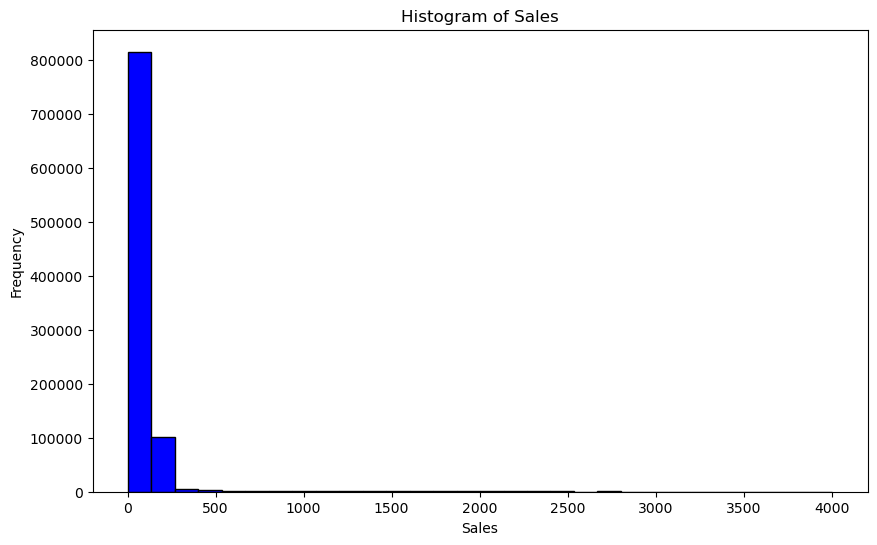

In [131]:
# Plotting Histogram to reveals how the data is distributed across the datafream, showing skewness and outliers.
plt.figure(figsize=(10, 6))
plt.hist(assessment['sales'], bins=30, color='blue', edgecolor='black')
plt.title('Histogram of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

In [132]:
# Applying log transformation to fix skewness
assessment['sales_log'] = np.log(assessment['sales'])

In [133]:
# Calculating skewness after log transformation
skewness_og_log = assessment['sales_log'].skew()
skewness_og_log

np.float64(-0.29699003705421395)

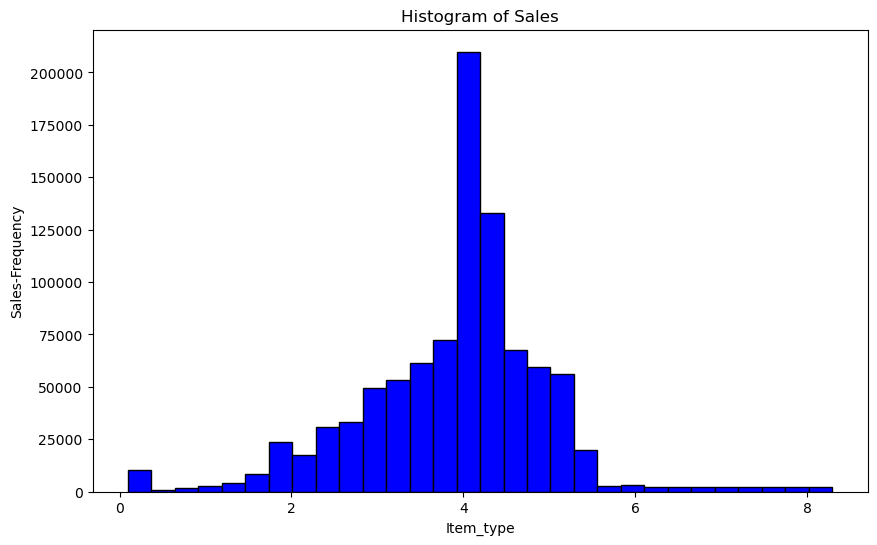

In [134]:
# Displaying histogram after log transformation
plt.figure(figsize=(10, 6))
plt.hist(assessment['sales_log'], bins=30, color='blue', edgecolor='black')
plt.title('Histogram of Sales')
plt.xlabel('Item_type')
plt.ylabel('Sales-Frequency')
plt.show()

In [135]:
#Show the descriptive statistics of the dataset after log transform
assessment.describe()

,sales_date,customer_district_code,item_type,sales,sales_log
count,9.404680e+05,940468.000000,940468.000000,940468.000000,940468.000000
mean,2.019454e+07,385.358194,5.883835,97.567557,3.902095
std,1.905844e+05,152.283711,1.848675,262.795100,1.080476
min,2.014030e+07,100.000000,1.000000,1.100000,0.095310
25%,2.017101e+07,300.000000,5.000000,29.100000,3.370738
50%,2.020101e+07,400.000000,7.000000,53.520000,3.980055
75%,2.022101e+07,500.000000,7.000000,84.700000,4.439116
max,2.027401e+08,720.000000,9.000000,4002.700000,8.294724


The histogram represents the distribution of the sales of lighting products. It shows a right-skewed distribution that have data clustered between item type 2 and 5. The histogram also shows that sales frequency concentrated at item type 4. The sales frequency of item 6 to 9. This shows on the long tail of the hisogram.

# Answer to Section 3: Analysis (10 Marks) - do not add any extra cells

## Visualisation 1 (all the codes in one cell) 

                  sales
sales_year             
2014         5307621.45
2015         7466540.90
2016         8384452.83
2017         8133327.69
2018         8914130.47
2019         5660421.42
2020        15735088.74
2021         7394436.76
2022         7718877.77
2023         9376449.96
2024         7667817.23


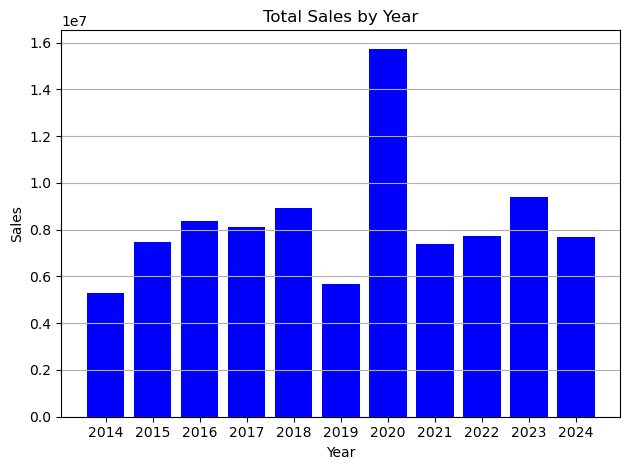

In [136]:
#Plotting the bar chart for the total sales between 2014-2024
total_sales_year = assessment.groupby('sales_year')[['sales']].sum()
print (total_sales_year)

plt.bar(total_sales_year.index, total_sales_year['sales'], color='blue')
plt.title ('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.grid (axis='y')
plt.tight_layout()

#Showing the bar chart
plt.show()

The bar chart shows the total sales generated between the year 2014 and 2024. The chart illustrates the annual sales of lighting products remain stable between 2014 and 2019. In 2020, there was a huge increase in sales, from 6 million to almost 16 million, which is equal to more than 160% increase. This sharp rise could be triggered by factors such as internal influence and external influence. Following this huge increase, the sales dropped significantly to below 8 million. The annual sales from 2021 to 2024 remain steady around 8 million, although in 2023, there was increase from 8million to almost 10million.  Overall, the trend suggest that annual sales are generally consistent with steady pattern, however, the surge in 2020 may have been driven by the external factor, of which is the pandemic year, where there was a national lockdow.

## Visualisation 2 (all the codes in one cell) 

business_chain_name
Metro Electrical Distributors    19908094.79
Inter Global Trading             15524883.47
Next Gen Electrical Solutions     9390307.49
Builders Supply Network           6750996.83
Bright Power Solutions            6684191.29
Name: sales, dtype: float64


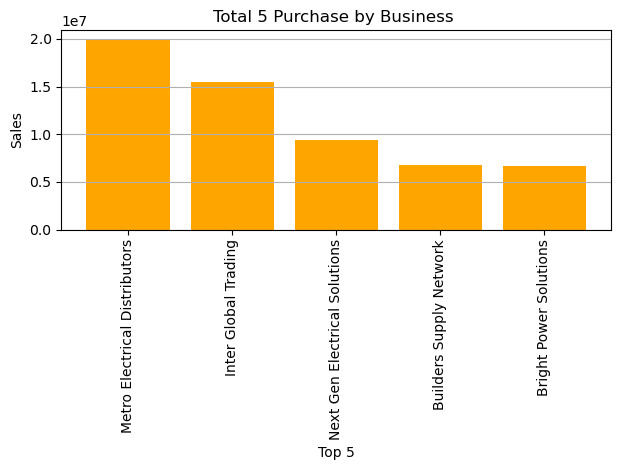

In [137]:
#Plotting the bar chart for the Top 5 Business Chain that purchase the lighting products
top_5_Business_Purchase = assessment.groupby('business_chain_name')['sales'].sum().nlargest(5)
print (top_5_Business_Purchase)

plt.bar(top_5_Business_Purchase.index, top_5_Business_Purchase, color='orange')
plt.title ('Total 5 Purchase by Business ')
plt.xlabel('Top 5')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.grid (axis='y')
plt.tight_layout()

#Showing the bar chart
plt.show()

The chart shows the five largest business that contributes to the sales between 2014 to 2024. It was shown that Metro Electrical Distributors has the highest amount of purchase reaching almost 20million in 10 years. Following this contributions, Inter Global Trading also made a combined purchased in the mount of 15 million, making them the second largest purchaser. Following Inter Global Trading is Next Gen Electrical Solutions which made total purchase in the amount of 10 million. Builders Supply Network and Bight Power Solutions share the same total purchase with just slightly over 5 million. The main insights that can be taken from these insights is the concentration of sales on 5 businesses which can be turn into opportunities to explore a stronger partnership. However, the lighting suppliers also expose to the risk of dependency on these businesses.

## Visualisation 3 (all the codes in one cell) 

salesperson_code
T300    4372000.42
T909    4064717.32
P342    3683771.09
P344    3267625.66
T215    3190095.21
Name: sales, dtype: float64


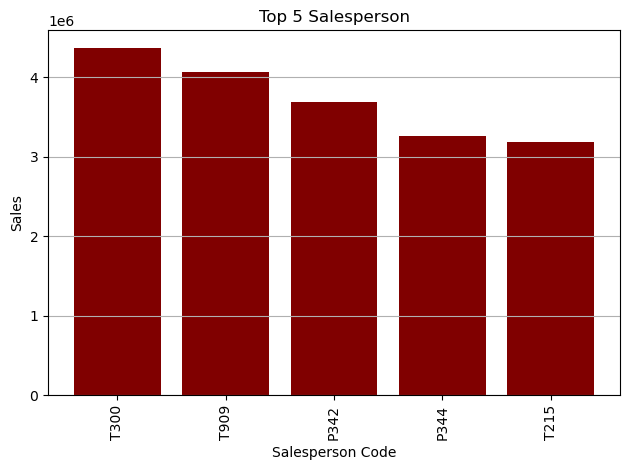

In [138]:
#Plotting the bar chart for the Top 5 Salesperson Performance
top_5_salesperson = assessment.groupby('salesperson_code')['sales'].sum().nlargest(5)
print (top_5_salesperson)

plt.bar(top_5_salesperson.index, top_5_salesperson, color='maroon')
plt.title ('Top 5 Salesperson')
plt.xlabel('Salesperson Code')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.grid (axis='y')
plt.tight_layout()

#Showing the bar chart
plt.show()

The chart illustrates the top salesperson that responsible for generating sales between 2014 and 2024. From the chart, we can see that Salesperson with code T300 achieved the highest sales, exceeding 4 million. Following T300 is T909 which the sales achievement also reaching 4 million. This indicates that there was a strong competition between T300 and T909 to achieve the highest sales. Moreover, the salesperson with code P342 generated the sales closely to 4 million. The fourth and fifth place are P344 and T215, generated total sales in the amount of around 3.2 million. From these insights, we can assume that the competition of the top salespersons is strong and indicate that their performance has contributes the most to the sales generation for the company. 

## Visualisation 4 (all the codes in one cell) 

customer_district_code
200.0    17131014.12
300.0    15917240.64
720.0    15525482.35
400.0    14160596.15
600.0     8464878.22
Name: sales, dtype: float64


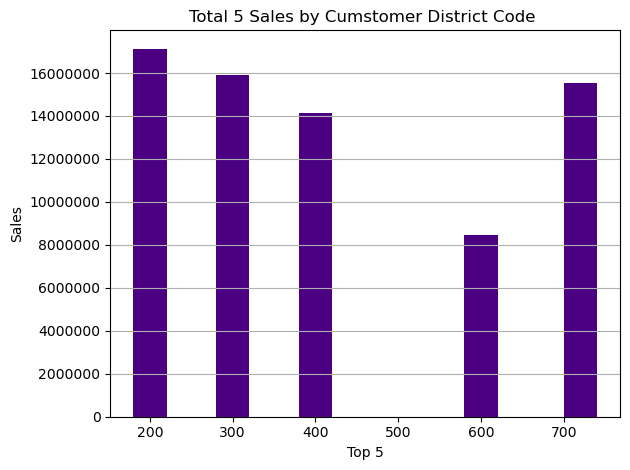

In [139]:
#Plotting the bar chart for the Top 5 Sales by Customer District Code
sales_ctm_ds_code = assessment.groupby('customer_district_code')['sales'].sum().nlargest(5)
print (sales_ctm_ds_code)

plt.bar(sales_ctm_ds_code.index, sales_ctm_ds_code, color='Indigo',width=40)

plt.title ('Total 5 Sales by Cumstomer District Code ')
plt.xlabel('Top 5')
plt.ylabel('Sales')
plt.grid (axis='y')
plt.ticklabel_format(style='plain', axis='y') 
plt.tight_layout()

#Showing the bar chart
plt.show()

The bar chart illustrates the highest sales based on customer district code. The chart shows that the customer with district code 200 has the highest contribution to sales between 2014 and 2024, exceeding the value of 16 million. The district with code 300 and 700 shares similar number of sales with each has the sales figures in the amount of over 15 million. With this amount, it has shown that the sales to customer from district code 200, 300, and 700 accumulate to almost 50 million. Additionally, the district with code 400 shows a good sales value in the amount of slightly above 14 million. In contrast, the district with code 600 shows a significant difference in terms of sales as the value only accounted for around 8.5 million, which is a 100% difference compared to district with code 200. These patterns offer valuable insights for the marketing department as this indicates that the supplying of the lighting concentrated in a few districts. Therefore, other districts that are in the supplying portfolio may require stronger marketing campaign or strong salesperson deployment to boost sales in the poor performance districts.

## Visualisation 5 (all the codes in one cell) 

                    sales
light_source             
Accessories   23257662.97
LED            4795888.31
Traditional   63705613.94


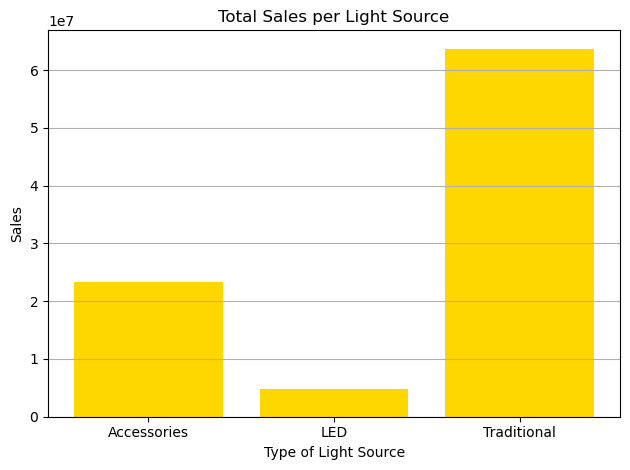

In [140]:
#Plotting the bar chart for the Total Sales by Light Source
sales_light_source = assessment.groupby('light_source')[['sales']].sum()
print (sales_light_source)

plt.bar(sales_light_source.index, sales_light_source['sales'], color='gold')
plt.title ('Total Sales per Light Source')
plt.xlabel('Type of Light Source')
plt.ylabel('Sales')
plt.grid (axis='y')
plt.tight_layout()

#Showing the bar chart
plt.show()

The bar chart shows the total revenue generated from the sales of lighting based on the source of light such as Traditional, LED, and Accessories. The chart illustrates that the traditional source has dominate the sales value over the other two sources, generated over 60 millions of sales, substantially 3 times more than the two sources combined. The lighting accessories has generated sales slightly above 20 million. Meanwhile, the LED has only contributed around 10 million to the total sales. From this chart we can gain further insight into the market of lighting by source of light. Despite, the market is growing and leaning towards energy efficient LED lighting, the traditional lightings remain the market dominant light source. However, the awareness and time lag to switch to energy efficient LED provided the opportunity for the suppliers to prepare and adopt new strategies to compete in the new trend of the lighting market.

In [141]:
assessment.to_excel('Assessment 01.xlsx', index=False)